# Deep portfolio optimisation under the Heston model

This notebook studies portfolio optimisation using deep learning under the Heston stochastic volatility model.

Under a self-financing trading strategy $\phi=(\phi_n)_{n=0,1,\dots,N-1}$ and zero risk-free interest rate, the portfolio value satisfies
$$
X_{n+1}-X_n=\phi_n(S_{n+1}-S_n),
$$
so that
$$
X_N=x_0+\sum_{n=0}^{N-1}\phi_n(S_{n+1}-S_n).
$$

Our objective is to solve
$$
\sup_{\phi}\mathbb{E}[U(X_N)],
$$
with exponential utility
$$
U(x)=-e^{-\gamma x}.
$$

The Heston model is given by
$$
dS_t = \mu S_t\,dt + \sqrt{Y_t}\,S_t\,dW_t^{(1)},
\qquad S_0=s_0,
$$
$$
dY_t = \kappa(\theta-Y_t)\,dt + \eta\sqrt{Y_t}\,dW_t^{(2)},
\qquad Y_0=y_0,
$$
with
$$
dW_t^{(1)}dW_t^{(2)}=\rho\,dt.
$$

Since the variance process $Y_t$ is observable, we let the trading strategy depend on time, stock price, and variance:
$$
\phi_n=f(t_n,S_n,Y_n).
$$

We then approximate $f$ by a feedforward neural network.

## GPU Configuration

For the purpose of faster neural network training, the necessary software was downloaded so that the TensorFlow training would take place on the creators NVIDIA GPU. For Windows, this involves degrading package versions to TensorFlow=2.10.0 and numpy=1.23.5 for compatability with CUDA Toolkit 11.2 available from https://developer.nvidia.com/cuda-11.2.0-download-archive. This also requires installation of cuDNN 8.1 from https://developer.nvidia.com/rdp/cudnn-archive. A helpful guide on this process can be found here: https://medium.com/@Rahul_Meduri/install-cuda-cudnn-in-conda-virtual-environment-and-setup-gpu-support-using-tensorflow-f8a4c942b6ea. If the marker wishes to not run code via the GPU, it will be indicated which code snippets are GPU code with #---GPU--- and the marker shoud comment these out 

We enable per-process GPU memory growth to avoid allocating the full VRAM upfront. Without this, TensorFlow reserves the entire available GPU memory on the first call, which can cause out-of-memory errors when the session is shared. Setting `memory_growth=True` allows the allocator to grow its pool incrementally as needed, which is particularly important given the large path batches ($M = 80{,}000$) and long time grids ($N = 252$) used in training.

In [46]:
import tensorflow as tf
print(tf.__version__)

# --------------- GPU code starts here ---------------
print(tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Enabled memory growth for:", gpus)
    except RuntimeError as e:
        print("Memory growth must be set before GPUs are initialised:", e)

# --------------- GPU code ends here -----------------

2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Enabled memory growth for: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Imports and Random Seeds

Library Uses: `numpy` for path simulation and array operations, `tensorflow` for neural network training and automatic differentiation, and `matplotlib` for all visualisations. The `gc` module is used to force garbage collection between bisection iterations (Question 3.3) to reclaim GPU memory after each `tf.keras.backend.clear_session()` call. The `os` library helps to set up filing paths to conveniently save figures generated

Random seeds are fixed in both NumPy and TensorFlow at the start of the notebook to ensure that results are reproducible across runs.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K # for some reason this was not being "resolved" so we had to use tf.
import gc
import os

np.random.seed(123456)
tf.random.set_seed(123456)

## Generation of random Heston paths using the Milstein method

We simulate the Heston model over one year using a daily grid. Since the variance process may become negative under a naive discretisation, we use a full-truncation modification and define
$$
\widetilde{Y}_n=\max(Y_n,0).
$$

Using the Milstein scheme with full truncation, we simulate the stock and variance processes by
$$
S_{n+1}
=
S_n
+
\mu S_n \Delta t
+
S_n\sqrt{\widetilde{Y}_n}\,\Delta W_n^{(1)}
+
\frac{1}{2}S_n\sqrt{\widetilde{Y}_n}\left(\frac{\eta\rho}{2}\right)\bigl((\Delta W_n^{(1)})^2-\Delta t\bigr),
$$
and
$$
Y_{n+1}
=
Y_n
+
\kappa(\theta-Y_n)\Delta t
+
\eta\sqrt{\widetilde{Y}_n}\,\Delta W_n^{(2)}
+
\frac{1}{4}\eta^2\bigl((\Delta W_n^{(2)})^2-\Delta t\bigr).
$$

To generate correlated Brownian increments, we set
$$
\Delta W_n^{(1)}=\sqrt{\Delta t}\,Z_{1,n},
$$
$$
\Delta W_n^{(2)}=\sqrt{\Delta t}\left(\rho Z_{1,n}+\sqrt{1-\rho^2}\,Z_{2,n}\right),
$$
where $Z_{1,n},Z_{2,n}\sim N(0,1)$ independently.


(2025) Numerical Analysis of Euler and Milstein Schemes with Applications to Multi-Asset Heston Models and Exotic Option Pricing. Available at: https://files.globalpresshub.com/wp-content/uploads/2025/09/Revised-ms_AJPAM_2116_v1.pdf (Accessed: 28 March 2026).

Shape of S: (100000, 253)
Shape of Y: (100000, 253)


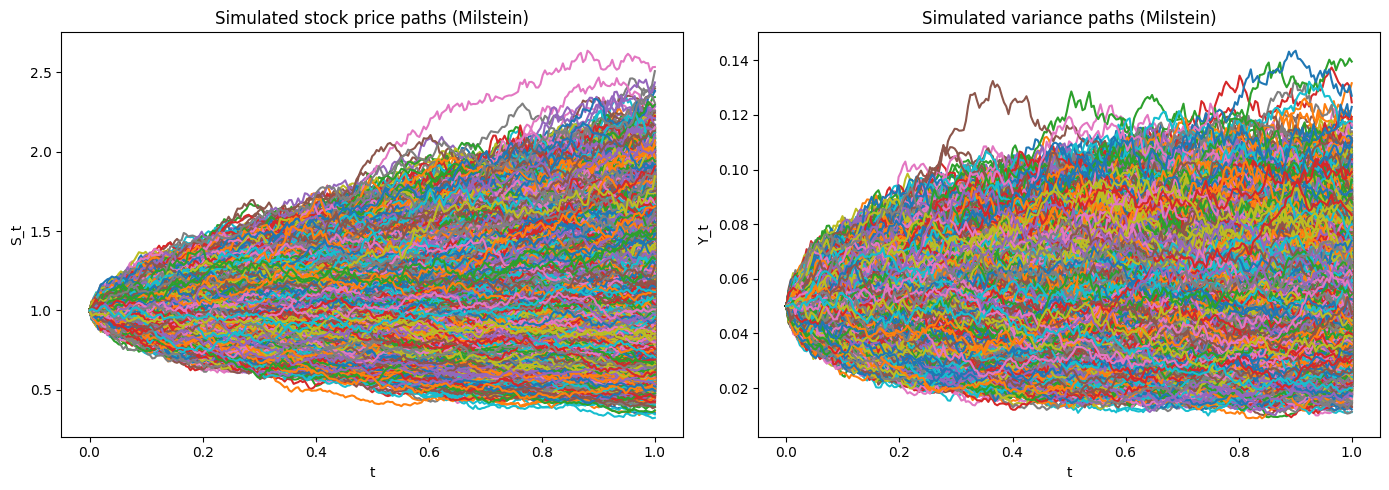

In [3]:
# Baseline parameters from the assignment
s0 = 1
y0 = 0.05
mu = 0.1
kappa = 1.2
theta = 0.05
eta = 0.1
rho = -0.5

T = 1
x0 = 1
gamma = 1

N = 252
M = 100000
dt = T / N

def simulate_heston_milstein(M, N, T, s0, y0, mu, kappa, theta, eta, rho):
    dt = T / N

    S = np.zeros((M, N + 1))
    Y = np.zeros((M, N + 1))

    S[:, 0] = s0
    Y[:, 0] = y0

    Z1 = np.random.normal(size=(M, N))
    Z2 = np.random.normal(size=(M, N))

    dW1 = np.sqrt(dt) * Z1
    dW2 = np.sqrt(dt) * (rho * Z1 + np.sqrt(1 - rho**2) * Z2)

    for n in range(N):
        Y_tilde = np.maximum(Y[:, n], 0)

        # Milstein update for stock process
        S[:, n + 1] = (S[:, n]+ mu * S[:, n] * dt+ S[:, n] * np.sqrt(Y_tilde) * dW1[:, n] + 0.5 * S[:, n] * np.sqrt(Y_tilde) * (eta * rho / 2) * (dW1[:, n]**2 - dt))

        # Milstein update for variance process with full truncation
        Y[:, n + 1] = (Y[:, n] + kappa * (theta - Y[:, n]) * dt + eta * np.sqrt(Y_tilde) * dW2[:, n] + 0.25 * eta**2 * (dW2[:, n]**2 - dt))

    return S, Y
S, Y = simulate_heston_milstein(M, N, T, s0, y0, mu, kappa, theta, eta, rho)
t = np.linspace(0, T, N + 1)

print("Shape of S:", S.shape)
print("Shape of Y:", Y.shape)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for i in range(M):
    ax[0].plot(t, S[i, :], label=f"Path {i+1}")
    ax[1].plot(t, Y[i, :], label=f"Path {i+1}")

ax[0].set_xlabel("t")
ax[0].set_ylabel("S_t")
ax[0].set_title("Simulated stock price paths (Milstein)")


ax[1].set_xlabel("t")
ax[1].set_ylabel("Y_t")
ax[1].set_title("Simulated variance paths (Milstein)")

plt.tight_layout()
plt.show()

## Specification of the neural network

We approximate the trading rule by a feedforward neural network.

Since the variance process is observable in the assignment, we let
$$
\phi_n=f(t_n,S_n,Y_n).
$$

For each simulated path, one training example consists of the sequence
$$
(t_0,S_0,Y_0),\,(t_1,S_1,Y_1),\,\dots,\,(t_{N-1},S_{N-1},Y_{N-1}),
$$
so the input shape is $(N,3)$.

The network then outputs the sequence
$$
\phi_0,\phi_1,\dots,\phi_{N-1}.
$$



In [48]:
# use HeNormal initialisation for ReLU layers
he_init = tf.keras.initializers.HeNormal(seed=123456)

# batch normalisation inserted between Dense and ReLU
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(N, 3)),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    # final output layer still linear, but also He-initialised for consistency
    tf.keras.layers.Dense(1, activation="linear", kernel_initializer=he_init)
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 252, 100)          300       
                                                                 
 batch_normalization (BatchN  (None, 252, 100)         400       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 252, 100)          0         
                                                                 
 dense_9 (Dense)             (None, 252, 100)          10000     
                                                                 
 batch_normalization_1 (Batc  (None, 252, 100)         400       
 hNormalization)                                                 
                                                                 
 activation_1 (Activation)   (None, 252, 100)          0

## Defining the loss function

The utility function is
$$
U(x)=-e^{-\gamma x}.
$$

For a predicted strategy $\hat{\phi}=(\hat{\phi}_0,\dots,\hat{\phi}_{N-1})$, the terminal wealth is
$$
X_N=x_0+\sum_{n=0}^{N-1}\hat{\phi}_n(S_{n+1}-S_n).
$$

If we define
$$
y_n=S_{n+1}-S_n,
$$
then we can write
$$
X_N=x_0+\hat{\phi}\cdot y.
$$

Hence the pathwise loss becomes
$$
\ell(y,\hat{\phi})=-U(X_N)=\exp\bigl(-\gamma(x_0+\hat{\phi}\cdot y)\bigr).
$$

When training the model, the label data will therefore be the stock increments $(S_1-s_0,\dots,S_N-S_{N-1})$.

In [49]:
def ExpUtilityLoss(y_true, y_pred):
    terminal_wealth = x0 + tf.reduce_sum(y_pred * y_true, axis=1)
    return tf.exp(-gamma * terminal_wealth)
    #tf.reduce_sum -> allows us to compute the add the values in the matrix. Using axis = 1 allows us to do it row by row.
    # Resorted to this method because import tensorflow.keras.backend as K was not beinf resolved

## Preparing the training data

The feature tensor is built as
$$
\text{xtrain}[m,n,:]=(t_n,S_n^{(m+1)},Y_n^{(m+1)}),
$$
so xtrain has shape $(M,N,3)$.

The label matrix is
$$
\text{ytrain}[m,n]=S_{n+1}^{(m+1)}-S_n^{(m+1)},
$$
so ytrain has shape $(M,N)$.

In [50]:
xtrain = np.stack([
    np.tile(t[:N], (M, 1)),
    S[:, :N],
    Y[:, :N]
], axis=-1)

ytrain = np.diff(S, axis=1)

print("Shape of xtrain:", xtrain.shape)
print("Shape of ytrain:", ytrain.shape)

Shape of xtrain: (100000, 252, 3)
Shape of ytrain: (100000, 252)


## Train-validation split

To track model performance properly, we split the simulated paths into training and validation samples.

This allows us to plot both training loss and validation loss during optimisation.

In [51]:
# We allocated 80% of the data to training the model and 20% to validate the model.

split = int(0.8 * M)

xtrain_fit = xtrain[:split]
ytrain_fit = ytrain[:split]

xval = xtrain[split:]
yval = ytrain[split:]

print("Training shapes:", xtrain_fit.shape, ytrain_fit.shape)
print("Validation shapes:", xval.shape, yval.shape)

Training shapes: (80000, 252, 3) (80000, 252)
Validation shapes: (20000, 252, 3) (20000, 252)


## Train the model

We now compile the neural network using the custom exponential-utility loss and train it on the simulated Heston paths.

In [52]:
num_epochs = 50
batch_size = 256

model.compile(optimizer=tf.keras.optimizers.Adam(), loss=ExpUtilityLoss)

history = model.fit(xtrain_fit, ytrain_fit, validation_data=(xval, yval), epochs= num_epochs, batch_size= batch_size, verbose= 1)

Epoch 1/50
313/313 [==============================] - 12s 31ms/step - loss: 0.3343 - val_loss: 0.3334
Epoch 2/50
313/313 [==============================] - 9s 30ms/step - loss: 0.3336 - val_loss: 0.3322
Epoch 3/50
313/313 [==============================] - 9s 30ms/step - loss: 0.3334 - val_loss: 0.3315
Epoch 4/50
313/313 [==============================] - 9s 29ms/step - loss: 0.3333 - val_loss: 0.3316
Epoch 5/50
313/313 [==============================] - 9s 30ms/step - loss: 0.3332 - val_loss: 0.3321
Epoch 6/50
313/313 [==============================] - 9s 29ms/step - loss: 0.3331 - val_loss: 0.3315
Epoch 7/50
313/313 [==============================] - 9s 29ms/step - loss: 0.3330 - val_loss: 0.3321
Epoch 8/50
313/313 [==============================] - 9s 29ms/step - loss: 0.3330 - val_loss: 0.3319
Epoch 9/50
313/313 [==============================] - 9s 30ms/step - loss: 0.3330 - val_loss: 0.3315
Epoch 10/50
313/313 [==============================] - 9s 29ms/step - loss: 0.3330 - val_l

(None, 252, 1)


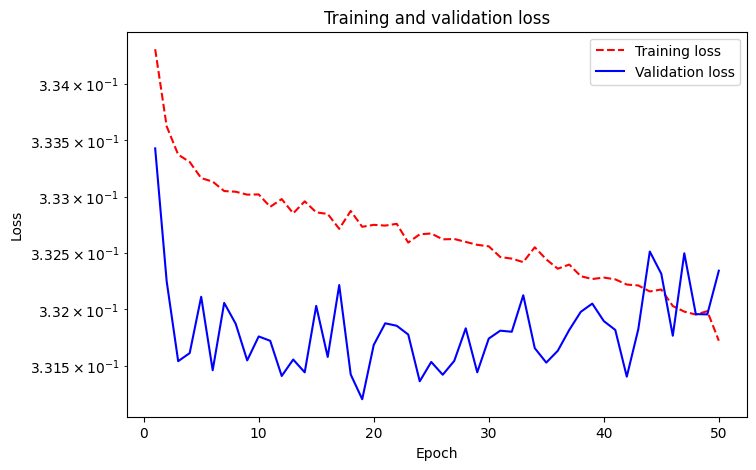

In [53]:
print(model.output_shape)

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training and validation loss")
plt.legend()
plt.show()

# This gives us the the training loss and validation loss graphs to see whether or not we are seeing overfitting or not and whether we should try different epochs, dropout layer, simpler model or L1/L2 modifications to the weightings.

# Note that the seed is dependent on Python version which was difficult to coordinate between developers, therefore there might be some discrepancy in the training loss graphs. However the trading behaviour graphs are identical anyway

## Properties of the optimal trading strategy

Once the model is trained, we can study the learned strategy

$$
\phi(t,S,Y).
$$

We will analyse how the strategy varies with both stock price and instantaneous variance, so we look at:

1. $\phi$ against $S$ for fixed $t$ and fixed $Y$,
2. $\phi$ against $S$ for fixed $t$ and different values of $Y$.

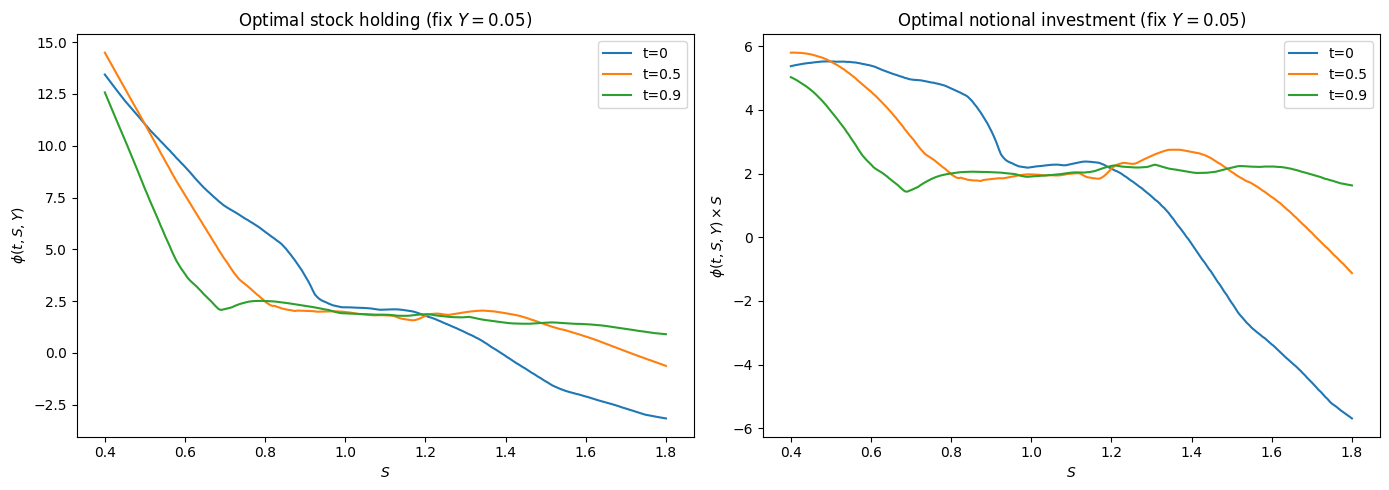

In [10]:
# (2) Phi against S with different fixed t and fixed Y
list_t = [0, 0.5, 0.9]
fix_y = 0.05
s_range = np.linspace(0.4, 1.8, N)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for fix_t in list_t:
    X_input = np.array([[[fix_t, s, fix_y] for s in s_range]])
    phi = model.predict(X_input, verbose=0).flatten()

    ax[0].plot(s_range, phi, label=f"t={fix_t}")
    ax[1].plot(s_range, phi * s_range, label=f"t={fix_t}")

ax[0].set_xlabel(r"$S$")
ax[0].set_ylabel(r"$\phi(t,S,Y)$")
ax[0].set_title(r"Optimal stock holding (fix $Y=0.05$)")

ax[1].set_xlabel(r"$S$")
ax[1].set_ylabel(r"$\phi(t,S,Y)\times S$")
ax[1].set_title(r"Optimal notional investment (fix $Y=0.05$)")

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

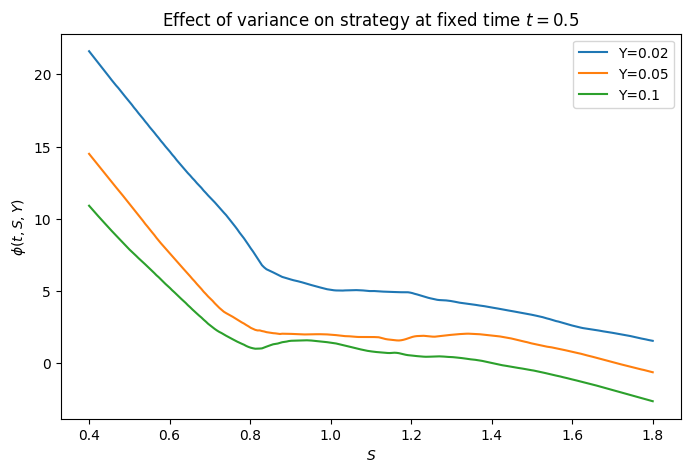

In [11]:
fix_t = 0.5
list_y = [0.02, 0.05, 0.10]

plt.figure(figsize=(8, 5))

for fix_y in list_y:
    X_input = np.array([[[fix_t, s, fix_y] for s in s_range]])
    phi = model.predict(X_input, verbose=0).flatten()
    plt.plot(s_range, phi, label=f"Y={fix_y}")

plt.xlabel(r"$S$")
plt.ylabel(r"$\phi(t,S,Y)$")
plt.title(rf"Effect of variance on strategy at fixed time $t={fix_t}$")
plt.legend()
plt.show()

## Distribution of terminal wealth

To evaluate the strategy, we compute the terminal wealth on the validation sample:
$$
X_N=x_0+\sum_{n=0}^{N-1}\phi_n(S_{n+1}-S_n),
$$
and then plot its distribution.

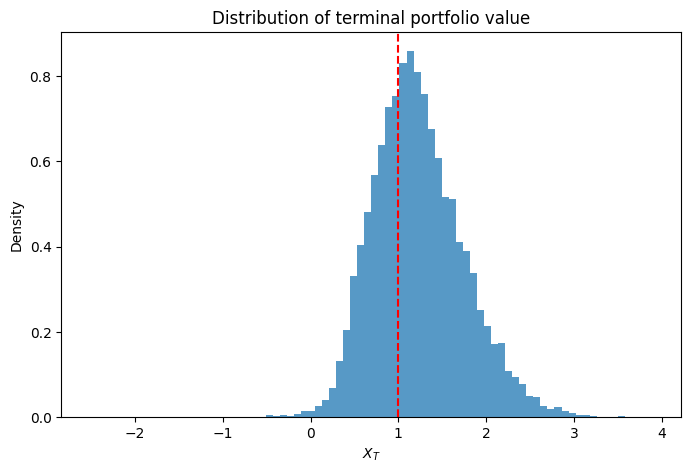

Mean terminal wealth: 1.2297082286715721
Std. dev. of terminal wealth: 0.5206891309263587
Mean utility: -0.3328775037578507


In [12]:
phi_val = model.predict(xval, verbose=0).squeeze(-1)
X_terminal = x0 + np.sum(phi_val * yval, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(X_terminal, bins=80, density=True, alpha=0.75)
plt.axvline(x0, color="red", linestyle="--", label=f"InitiL Wealth={x0}")
plt.xlabel(r"$X_T$")
plt.ylabel("Density")
plt.title("Distribution of terminal portfolio value")
plt.show()

print("Mean terminal wealth:", np.mean(X_terminal))
print("Std. dev. of terminal wealth:", np.std(X_terminal))
print("Mean utility:", np.mean(-np.exp(-gamma * X_terminal)))

## Extension: portfolio optimisation with terminal floor $X_T \ge C$

The assignment also asks for an extension where the portfolio value is not allowed to fall below
$$
C=0.75.
$$

A simple way to incorporate this into deep learning is to add a penalty for terminal wealth falling below $C$:
$$
\ell_C(y,\hat{\phi})
=
\exp\bigl(-\gamma(x_0+\hat{\phi}\cdot y)\bigr)
+
\lambda\bigl(C-(x_0+\hat{\phi}\cdot y)\bigr)_+^2,
$$
where
$$
(a)_+=\max(a,0).
$$

This does not impose the constraint exactly, but it penalises violations heavily and is easy to implement.

Reference: Poczos, B. and Tibshirani, R. (2013) 10-725: Optimization fall 2013 lecture 16: Penalty methods. Available at: https://www.stat.cmu.edu/~ryantibs/convexopt-F13/scribes/lec16.pdf (Accessed: 28 March 2026).

In [13]:
C = 0.75

# we will try different Lambdas we will try 50, 100, 200
lam = 200

def ExpUtilityLossConstrained(y_true, y_pred):
    terminal_wealth = x0 + tf.reduce_sum(y_pred * y_true, axis=1)

    utility_part = tf.exp(-gamma * terminal_wealth)
    penalty_part = lam * tf.square(tf.maximum(C - terminal_wealth, 0))

    return utility_part + penalty_part
#tf.reduce_sum -> allows us to compute the add the values in the matrix. Using axis = 1 allows us to do it row by row.
# Resorted to this method because import tensorflow.keras.backend as K was not beinf resolved

In [14]:
#same He normal + Batch Normalisation structure for constrained model
constrained_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(N, 3)),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(1, activation="linear", kernel_initializer=he_init)
])

constrained_model.compile(optimizer=tf.keras.optimizers.Adam(),loss=ExpUtilityLossConstrained)

history_c = constrained_model.fit(xtrain_fit, ytrain_fit, validation_data=(xval, yval), epochs=num_epochs, batch_size=batch_size, verbose=1)

Epoch 1/50
313/313 [==============================] - 14s 35ms/step - loss: 0.3481 - val_loss: 0.3427
Epoch 2/50
313/313 [==============================] - 10s 32ms/step - loss: 0.3415 - val_loss: 0.3393
Epoch 3/50
313/313 [==============================] - 10s 32ms/step - loss: 0.3411 - val_loss: 0.3387
Epoch 4/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3409 - val_loss: 0.3389
Epoch 5/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3412 - val_loss: 0.3396
Epoch 6/50
313/313 [==============================] - 10s 32ms/step - loss: 0.3407 - val_loss: 0.3392
Epoch 7/50
313/313 [==============================] - 10s 32ms/step - loss: 0.3405 - val_loss: 0.3384
Epoch 8/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3406 - val_loss: 0.3384
Epoch 9/50
313/313 [==============================] - 10s 32ms/step - loss: 0.3405 - val_loss: 0.3383
Epoch 10/50
313/313 [==============================] - 10s 32ms/step - loss: 0.340

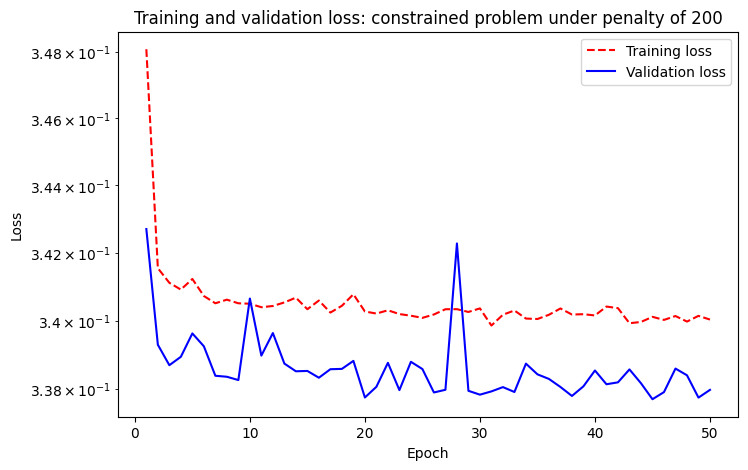

In [15]:
# Validation and training loss grpaah

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), history_c.history["loss"], "r--", label="Training loss")
plt.plot(range(1, num_epochs + 1), history_c.history["val_loss"], "b-", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training and validation loss: constrained problem under penalty of 200")
plt.legend()
plt.show()

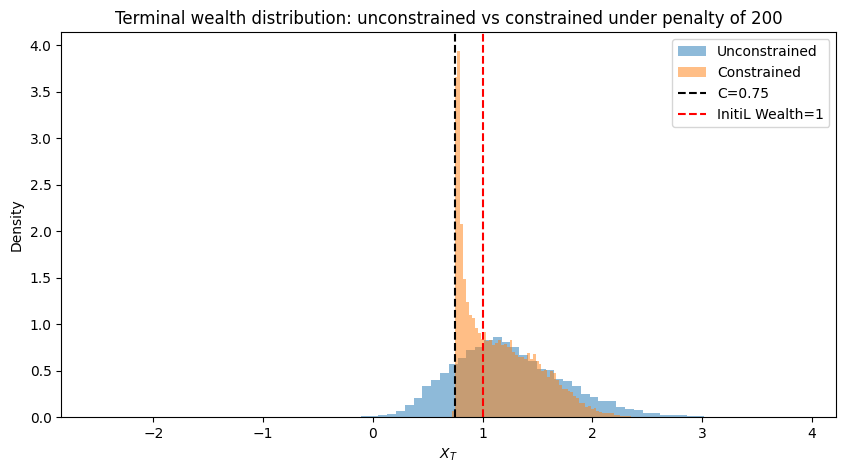

Unconstrained violation probability: 0.1746
Constrained violation probability: 0.00645


In [16]:
# The comparison between the terminal wealth under the Floor constraint X_T >= 0.75 and without the constraint

phi_uncon = model.predict(xval, verbose=0).squeeze(-1)
XT_uncon = x0 + np.sum(phi_uncon * yval, axis=1)

phi_con = constrained_model.predict(xval, verbose=0).squeeze(-1)
XT_con = x0 + np.sum(phi_con * yval, axis=1)

plt.figure(figsize=(10, 5))
plt.hist(XT_uncon, bins=80, density=True, alpha=0.5, label="Unconstrained")
plt.hist(XT_con, bins=80, density=True, alpha=0.5, label="Constrained")
plt.axvline(C, color="black", linestyle="--", label=f"C={C}")
plt.axvline(x0, color="red", linestyle="--", label=f"InitiL Wealth={x0}")
plt.xlabel(r"$X_T$")
plt.ylabel("Density")
plt.title("Terminal wealth distribution: unconstrained vs constrained under penalty of 200")
plt.legend()
plt.show()

print("Unconstrained violation probability:", np.mean(XT_uncon < C))
print("Constrained violation probability:", np.mean(XT_con < C))

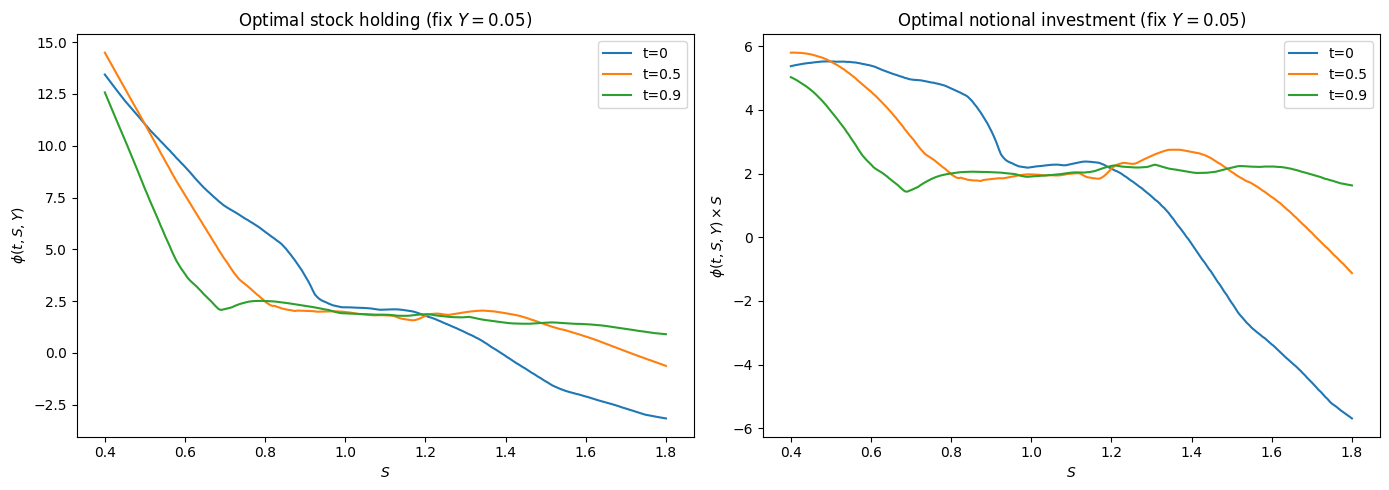

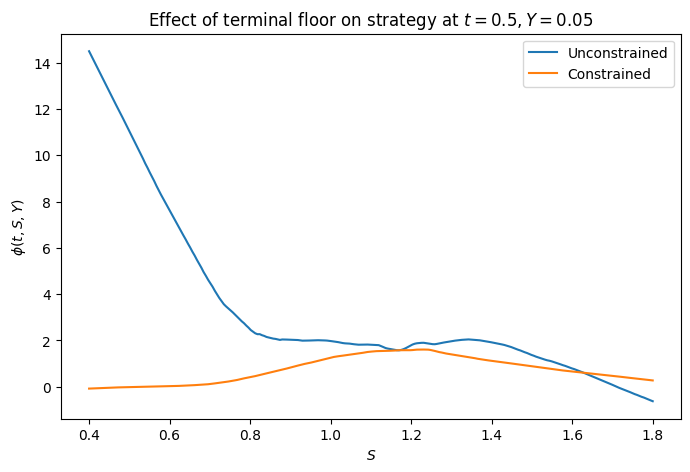

In [17]:
# This shows how risk control from the constraint changes the behaviour of the stratergy, not only the final wealth distribution
# Fixed t = 0.5 and fixed y = 0.05 as an example
# (2) Phi against S with different fixed t and fixed Y
list_t = [0, 0.5, 0.9]
fix_y = 0.05
s_range = np.linspace(0.4, 1.8, N)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for fix_t in list_t:
    X_input = np.array([[[fix_t, s, fix_y] for s in s_range]])
    phi = model.predict(X_input, verbose=0).flatten()

    ax[0].plot(s_range, phi, label=f"t={fix_t}")
    ax[1].plot(s_range, phi * s_range, label=f"t={fix_t}")

ax[0].set_xlabel(r"$S$")
ax[0].set_ylabel(r"$\phi(t,S,Y)$")
ax[0].set_title(r"Optimal stock holding (fix $Y=0.05$)")

ax[1].set_xlabel(r"$S$")
ax[1].set_ylabel(r"$\phi(t,S,Y)\times S$")
ax[1].set_title(r"Optimal notional investment (fix $Y=0.05$)")

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()


fix_t = 0.5
fix_y = 0.05

X_input = np.array([[[fix_t, s, fix_y] for s in s_range]])

phi_uncon_plot = model.predict(X_input, verbose=0).flatten()
phi_con_plot = constrained_model.predict(X_input, verbose=0).flatten()

plt.figure(figsize=(8, 5))
plt.plot(s_range, phi_uncon_plot, label="Unconstrained")
plt.plot(s_range, phi_con_plot, label="Constrained")
plt.xlabel(r"$S$")
plt.ylabel(r"$\phi(t,S,Y)$")
plt.title(rf"Effect of terminal floor on strategy at $t={fix_t}, Y={fix_y}$")
plt.legend()
plt.show()

Epoch 1/50
313/313 [==============================] - 13s 34ms/step - loss: 0.3451 - val_loss: 0.3411
Epoch 2/50
313/313 [==============================] - 10s 32ms/step - loss: 0.3410 - val_loss: 0.3395
Epoch 3/50
313/313 [==============================] - 10s 32ms/step - loss: 0.3410 - val_loss: 0.3380
Epoch 4/50
313/313 [==============================] - 10s 32ms/step - loss: 0.3405 - val_loss: 0.3384
Epoch 5/50
313/313 [==============================] - 10s 32ms/step - loss: 0.3406 - val_loss: 0.3388
Epoch 6/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3401 - val_loss: 0.3383
Epoch 7/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3403 - val_loss: 0.3385
Epoch 8/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3403 - val_loss: 0.3386
Epoch 9/50
313/313 [==============================] - 10s 32ms/step - loss: 0.3403 - val_loss: 0.3383
Epoch 10/50
313/313 [==============================] - 10s 32ms/step - loss: 0.340

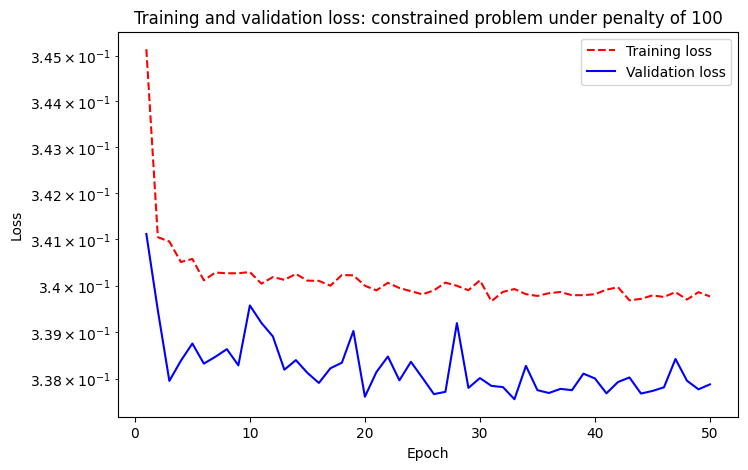

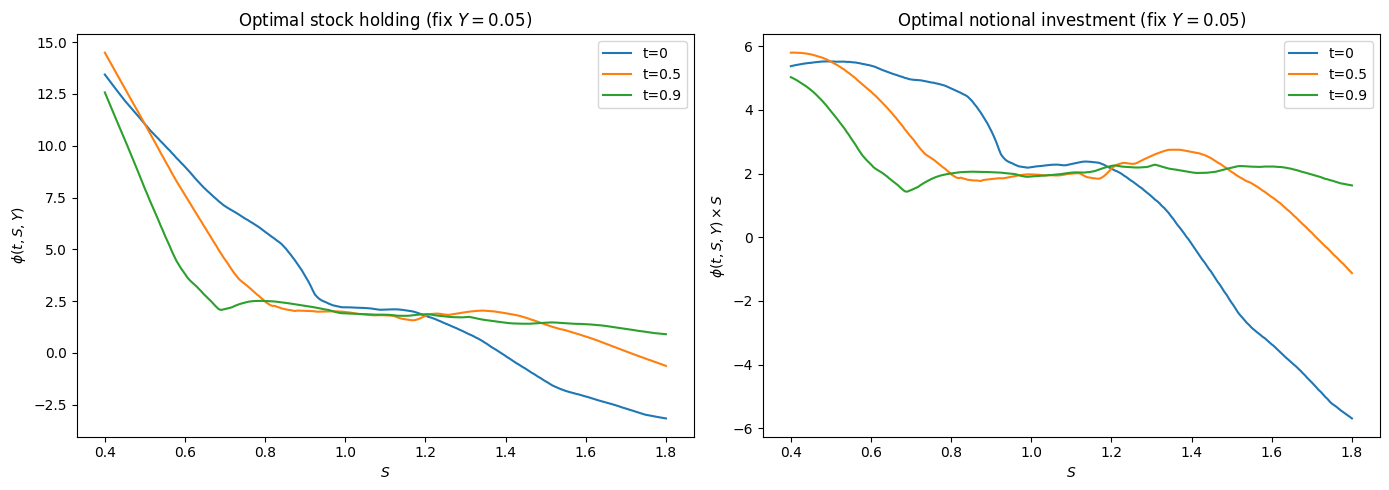

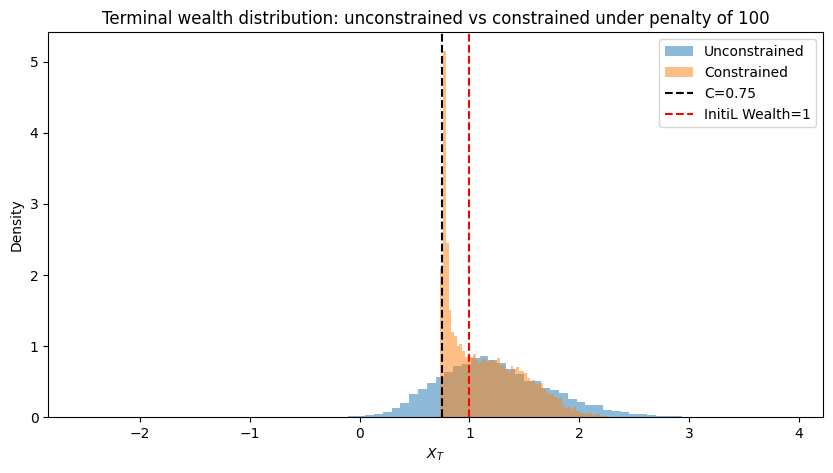

Unconstrained violation probability: 0.1746
Constrained violation probability: 0.01215


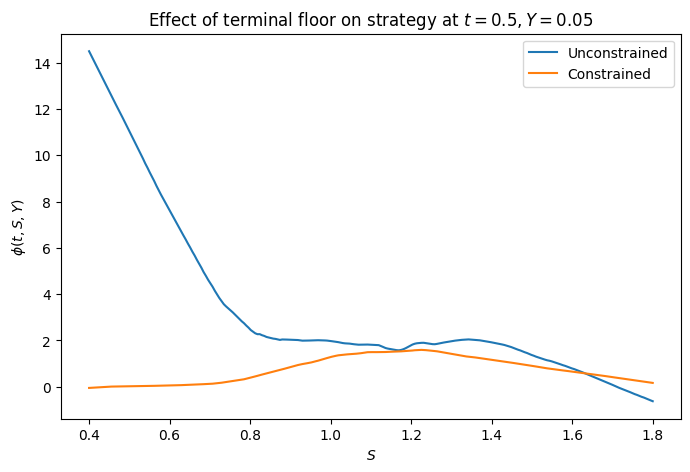

In [18]:
C = 0.75

# we will try different Lambdas we will try 50, 100, 200
lam = 100

def ExpUtilityLossConstrained(y_true, y_pred):
    terminal_wealth = x0 + tf.reduce_sum(y_pred * y_true, axis=1)

    utility_part = tf.exp(-gamma * terminal_wealth)
    penalty_part = lam * tf.square(tf.maximum(C - terminal_wealth, 0))

    return utility_part + penalty_part
#tf.reduce_sum -> allows us to compute the add the values in the matrix. Using axis = 1 allows us to do it row by row.
# Resorted to this method because import tensorflow.keras.backend as K was not beinf resolved

#same He normal + Batch Normalisation structure for constrained model
constrained_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(N, 3)),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(1, activation="linear", kernel_initializer=he_init)
])

constrained_model.compile(optimizer=tf.keras.optimizers.Adam(),loss=ExpUtilityLossConstrained)

history_c = constrained_model.fit(xtrain_fit, ytrain_fit, validation_data=(xval, yval), epochs=num_epochs, batch_size=batch_size, verbose=1)



# Validation and training loss grpaah

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), history_c.history["loss"], "r--", label="Training loss")
plt.plot(range(1, num_epochs + 1), history_c.history["val_loss"], "b-", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training and validation loss: constrained problem under penalty of 100")
plt.legend()
plt.show()

# (2) Phi against S with different fixed t and fixed Y

list_t = [0, 0.5, 0.9]
fix_y = 0.05
s_range = np.linspace(0.4, 1.8, N)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for fix_t in list_t:
    X_input = np.array([[[fix_t, s, fix_y] for s in s_range]])
    phi = model.predict(X_input, verbose=0).flatten()

    ax[0].plot(s_range, phi, label=f"t={fix_t}")
    ax[1].plot(s_range, phi * s_range, label=f"t={fix_t}")

ax[0].set_xlabel(r"$S$")
ax[0].set_ylabel(r"$\phi(t,S,Y)$")
ax[0].set_title(r"Optimal stock holding (fix $Y=0.05$)")

ax[1].set_xlabel(r"$S$")
ax[1].set_ylabel(r"$\phi(t,S,Y)\times S$")
ax[1].set_title(r"Optimal notional investment (fix $Y=0.05$)")

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

# The comparison between the terminal wealth under the Floor constraint X_T >= 0.75 and without the constraint

phi_uncon = model.predict(xval, verbose=0).squeeze(-1)
XT_uncon = x0 + np.sum(phi_uncon * yval, axis=1)

phi_con = constrained_model.predict(xval, verbose=0).squeeze(-1)
XT_con = x0 + np.sum(phi_con * yval, axis=1)

plt.figure(figsize=(10, 5))
plt.hist(XT_uncon, bins=80, density=True, alpha=0.5, label="Unconstrained")
plt.hist(XT_con, bins=80, density=True, alpha=0.5, label="Constrained")
plt.axvline(C, color="black", linestyle="--", label=f"C={C}")
plt.axvline(x0, color="red", linestyle="--", label=f"InitiL Wealth={x0}")
plt.xlabel(r"$X_T$")
plt.ylabel("Density")
plt.title("Terminal wealth distribution: unconstrained vs constrained under penalty of 100")
plt.legend()
plt.show()

print("Unconstrained violation probability:", np.mean(XT_uncon < C))
print("Constrained violation probability:", np.mean(XT_con < C))


# This shows how risk control from the constrraint changes the behaviour of the stratergy, not only the final wealth distribution
# Fixed t = 0.5 and fixed y = 0.05 as an example
fix_t = 0.5
fix_y = 0.05

X_input = np.array([[[fix_t, s, fix_y] for s in s_range]])

phi_uncon_plot = model.predict(X_input, verbose=0).flatten()
phi_con_plot = constrained_model.predict(X_input, verbose=0).flatten()

plt.figure(figsize=(8, 5))
plt.plot(s_range, phi_uncon_plot, label="Unconstrained")
plt.plot(s_range, phi_con_plot, label="Constrained")
plt.xlabel(r"$S$")
plt.ylabel(r"$\phi(t,S,Y)$")
plt.title(rf"Effect of terminal floor on strategy at $t={fix_t}, Y={fix_y}$")
plt.legend()
plt.show()

Epoch 1/50
313/313 [==============================] - 12s 32ms/step - loss: 0.3434 - val_loss: 0.3404
Epoch 2/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3405 - val_loss: 0.3384
Epoch 3/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3403 - val_loss: 0.3379
Epoch 4/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3404 - val_loss: 0.3384
Epoch 5/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3402 - val_loss: 0.3382
Epoch 6/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3399 - val_loss: 0.3380
Epoch 7/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3400 - val_loss: 0.3382
Epoch 8/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3400 - val_loss: 0.3385
Epoch 9/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3400 - val_loss: 0.3379
Epoch 10/50
313/313 [==============================] - 10s 31ms/step - loss: 0.339

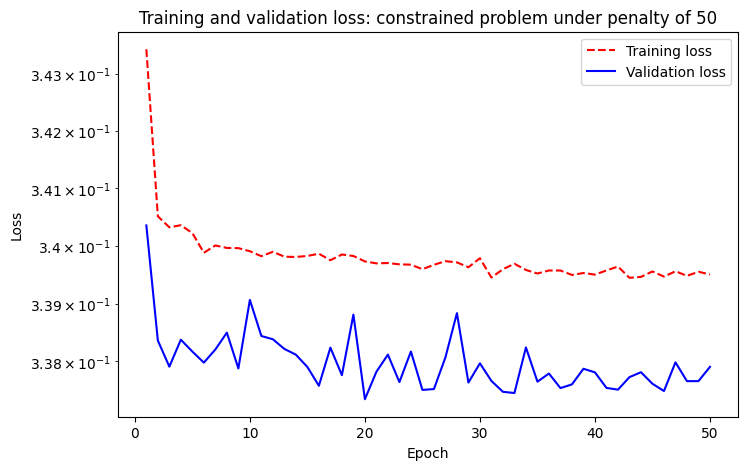

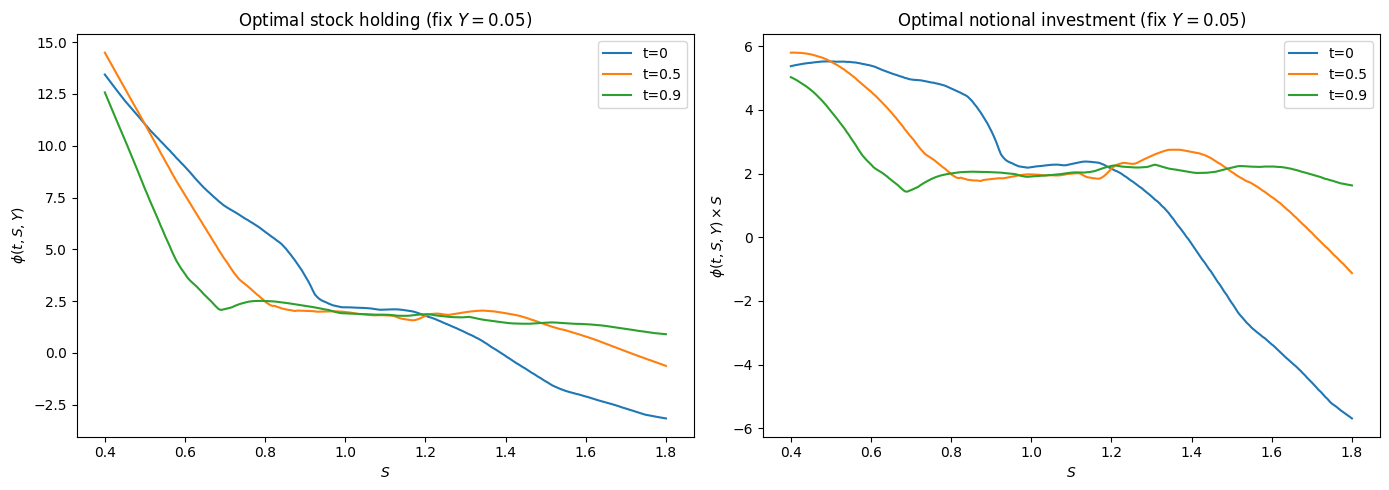

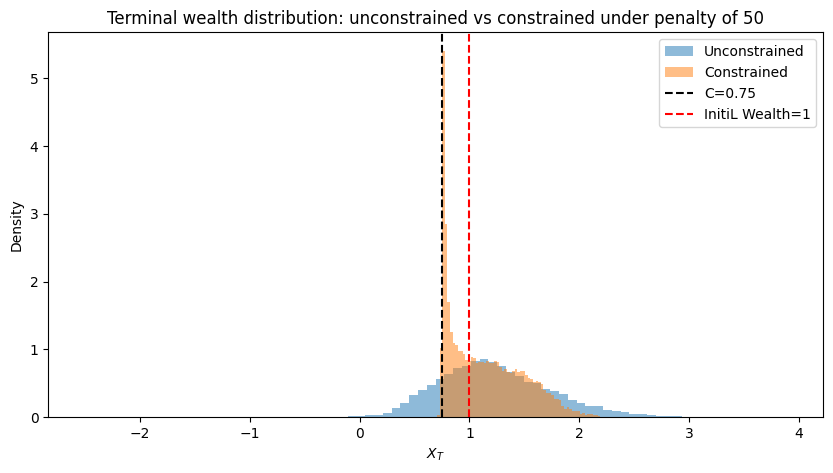

Unconstrained violation probability: 0.1746
Constrained violation probability: 0.02105


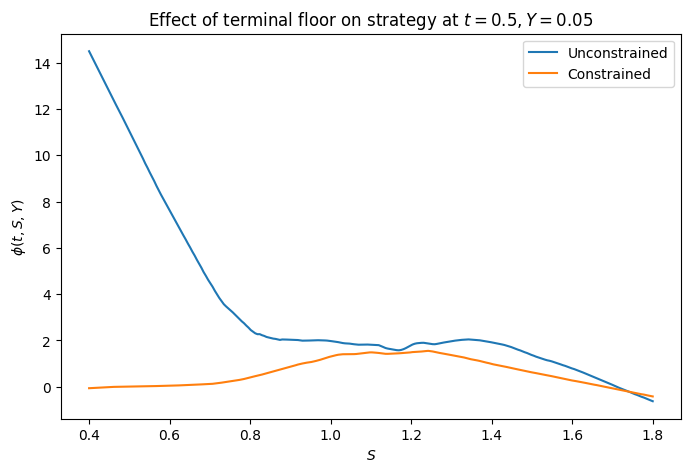

In [19]:
C = 0.75

# we will try different Lambdas we will try 50, 100, 200
lam = 50

def ExpUtilityLossConstrained(y_true, y_pred):
    terminal_wealth = x0 + tf.reduce_sum(y_pred * y_true, axis=1)

    utility_part = tf.exp(-gamma * terminal_wealth)
    penalty_part = lam * tf.square(tf.maximum(C - terminal_wealth, 0))

    return utility_part + penalty_part
#tf.reduce_sum -> allows us to compute the add the values in the matrix. Using axis = 1 allows us to do it row by row.
# Resorted to this method because import tensorflow.keras.backend as K was not beinf resolved

#same He normal + Batch Normalisation structure for constrained model
constrained_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(N, 3)),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(1, activation="linear", kernel_initializer=he_init)
])

constrained_model.compile(optimizer=tf.keras.optimizers.Adam(),loss=ExpUtilityLossConstrained)

history_c = constrained_model.fit(xtrain_fit, ytrain_fit, validation_data=(xval, yval), epochs=num_epochs, batch_size=batch_size, verbose=1)



# Validation and training loss grpaah

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), history_c.history["loss"], "r--", label="Training loss")
plt.plot(range(1, num_epochs + 1), history_c.history["val_loss"], "b-", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training and validation loss: constrained problem under penalty of 50")
plt.legend()
plt.show()


# (2) Phi against S with different fixed t and fixed Y

list_t = [0, 0.5, 0.9]
fix_y = 0.05
s_range = np.linspace(0.4, 1.8, N)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for fix_t in list_t:
    X_input = np.array([[[fix_t, s, fix_y] for s in s_range]])
    phi = model.predict(X_input, verbose=0).flatten()

    ax[0].plot(s_range, phi, label=f"t={fix_t}")
    ax[1].plot(s_range, phi * s_range, label=f"t={fix_t}")

ax[0].set_xlabel(r"$S$")
ax[0].set_ylabel(r"$\phi(t,S,Y)$")
ax[0].set_title(r"Optimal stock holding (fix $Y=0.05$)")

ax[1].set_xlabel(r"$S$")
ax[1].set_ylabel(r"$\phi(t,S,Y)\times S$")
ax[1].set_title(r"Optimal notional investment (fix $Y=0.05$)")

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()


# The comparison between the terminal wealth under the Floor constraint X_T >= 0.75 and without the constraint

phi_uncon = model.predict(xval, verbose=0).squeeze(-1)
XT_uncon = x0 + np.sum(phi_uncon * yval, axis=1)

phi_con = constrained_model.predict(xval, verbose=0).squeeze(-1)
XT_con = x0 + np.sum(phi_con * yval, axis=1)

plt.figure(figsize=(10, 5))
plt.hist(XT_uncon, bins=80, density=True, alpha=0.5, label="Unconstrained")
plt.hist(XT_con, bins=80, density=True, alpha=0.5, label="Constrained")
plt.axvline(C, color="black", linestyle="--", label=f"C={C}")
plt.axvline(x0, color="red", linestyle="--", label=f"InitiL Wealth={x0}")
plt.xlabel(r"$X_T$")
plt.ylabel("Density")
plt.title("Terminal wealth distribution: unconstrained vs constrained under penalty of 50")
plt.legend()
plt.show()

print("Unconstrained violation probability:", np.mean(XT_uncon < C))
print("Constrained violation probability:", np.mean(XT_con < C))


# This shows how risk control from the constrraint changes the behaviour of the stratergy, not only the final wealth distribution
# Fixed t = 0.5 and fixed y = 0.05 as an example
fix_t = 0.5
fix_y = 0.05

X_input = np.array([[[fix_t, s, fix_y] for s in s_range]])

phi_uncon_plot = model.predict(X_input, verbose=0).flatten()
phi_con_plot = constrained_model.predict(X_input, verbose=0).flatten()

plt.figure(figsize=(8, 5))
plt.plot(s_range, phi_uncon_plot, label="Unconstrained")
plt.plot(s_range, phi_con_plot, label="Constrained")
plt.xlabel(r"$S$")
plt.ylabel(r"$\phi(t,S,Y)$")
plt.title(rf"Effect of terminal floor on strategy at $t={fix_t}, Y={fix_y}$")
plt.legend()
plt.show()

Epoch 1/50
313/313 [==============================] - 12s 33ms/step - loss: 0.3677 - val_loss: 0.3524
Epoch 2/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3432 - val_loss: 0.3400
Epoch 3/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3419 - val_loss: 0.3395
Epoch 4/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3420 - val_loss: 0.3410
Epoch 5/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3439 - val_loss: 0.4282
Epoch 6/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3452 - val_loss: 0.3397
Epoch 7/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3421 - val_loss: 0.3394
Epoch 8/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3415 - val_loss: 0.3391
Epoch 9/50
313/313 [==============================] - 10s 31ms/step - loss: 0.3412 - val_loss: 0.3392
Epoch 10/50
313/313 [==============================] - 10s 31ms/step - loss: 0.342

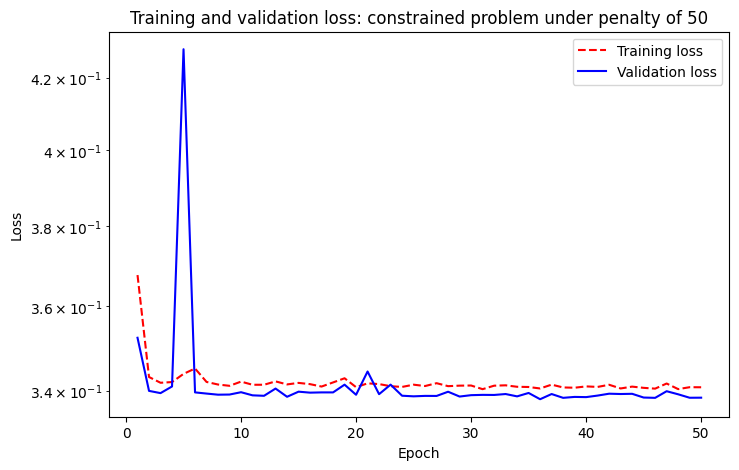

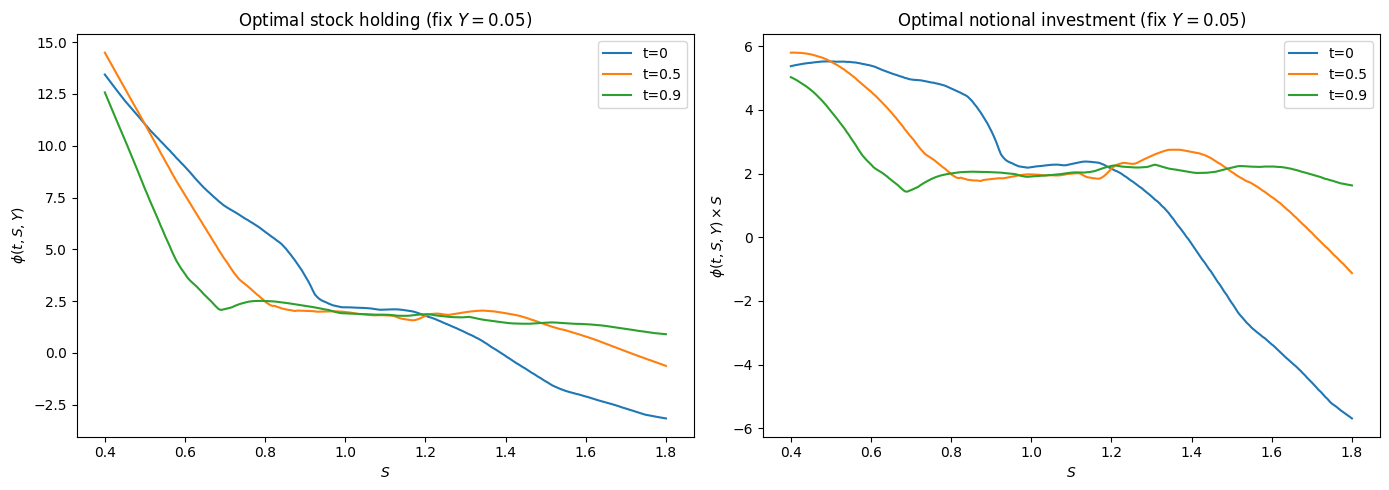

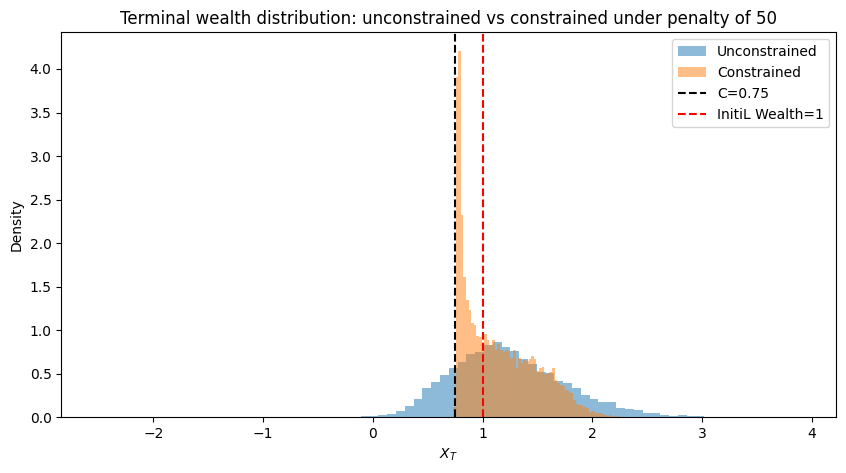

Unconstrained violation probability: 0.1746
Constrained violation probability: 0.0013


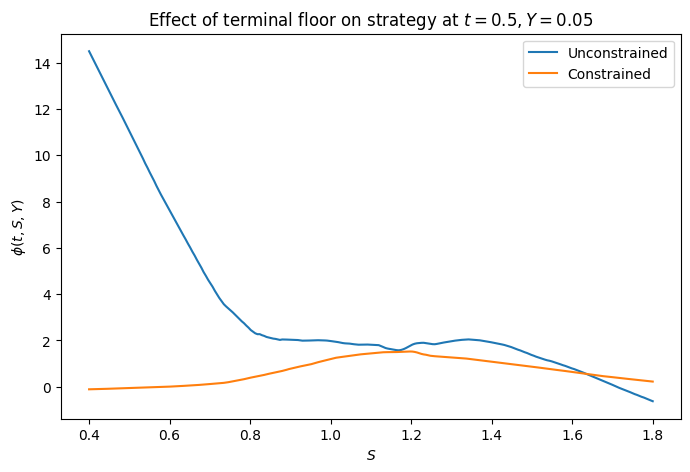

In [20]:
C = 0.75

# we will try different Lambdas we will try 50, 100, 200, 1000
lam = 1000

def ExpUtilityLossConstrained(y_true, y_pred):
    terminal_wealth = x0 + tf.reduce_sum(y_pred * y_true, axis=1)

    utility_part = tf.exp(-gamma * terminal_wealth)
    penalty_part = lam * tf.square(tf.maximum(C - terminal_wealth, 0))

    return utility_part + penalty_part
#tf.reduce_sum -> allows us to compute the add the values in the matrix. Using axis = 1 allows us to do it row by row.
# Resorted to this method because import tensorflow.keras.backend as K was not beinf resolved

#same He normal + Batch Normalisation structure for constrained model
constrained_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(N, 3)),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(100, use_bias=False, kernel_initializer=he_init),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Dense(1, activation="linear", kernel_initializer=he_init)
])

constrained_model.compile(optimizer=tf.keras.optimizers.Adam(),loss=ExpUtilityLossConstrained)

history_c = constrained_model.fit(xtrain_fit, ytrain_fit, validation_data=(xval, yval), epochs=num_epochs, batch_size=batch_size, verbose=1)



# Validation and training loss grpaah

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), history_c.history["loss"], "r--", label="Training loss")
plt.plot(range(1, num_epochs + 1), history_c.history["val_loss"], "b-", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Training and validation loss: constrained problem under penalty of 50")
plt.legend()
plt.show()

# (2) Phi against S with different fixed t and fixed Y

list_t = [0, 0.5, 0.9]
fix_y = 0.05
s_range = np.linspace(0.4, 1.8, N)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for fix_t in list_t:
    X_input = np.array([[[fix_t, s, fix_y] for s in s_range]])
    phi = model.predict(X_input, verbose=0).flatten()

    ax[0].plot(s_range, phi, label=f"t={fix_t}")
    ax[1].plot(s_range, phi * s_range, label=f"t={fix_t}")

ax[0].set_xlabel(r"$S$")
ax[0].set_ylabel(r"$\phi(t,S,Y)$")
ax[0].set_title(r"Optimal stock holding (fix $Y=0.05$)")

ax[1].set_xlabel(r"$S$")
ax[1].set_ylabel(r"$\phi(t,S,Y)\times S$")
ax[1].set_title(r"Optimal notional investment (fix $Y=0.05$)")

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()


# The comparison between the terminal wealth under the Floor constraint X_T >= 0.75 and without the constraint

phi_uncon = model.predict(xval, verbose=0).squeeze(-1)
XT_uncon = x0 + np.sum(phi_uncon * yval, axis=1)

phi_con = constrained_model.predict(xval, verbose=0).squeeze(-1)
XT_con = x0 + np.sum(phi_con * yval, axis=1)

plt.figure(figsize=(10, 5))
plt.hist(XT_uncon, bins=80, density=True, alpha=0.5, label="Unconstrained")
plt.hist(XT_con, bins=80, density=True, alpha=0.5, label="Constrained")
plt.axvline(C, color="black", linestyle="--", label=f"C={C}")
plt.axvline(x0, color="red", linestyle="--", label=f"InitiL Wealth={x0}")
plt.xlabel(r"$X_T$")
plt.ylabel("Density")
plt.title("Terminal wealth distribution: unconstrained vs constrained under penalty of 50")
plt.legend()
plt.show()

print("Unconstrained violation probability:", np.mean(XT_uncon < C))
print("Constrained violation probability:", np.mean(XT_con < C))


# This shows how risk control from the constrraint changes the behaviour of the stratergy, not only the final wealth distribution
# Fixed t = 0.5 and fixed y = 0.05 as an example
fix_t = 0.5
fix_y = 0.05

X_input = np.array([[[fix_t, s, fix_y] for s in s_range]])

phi_uncon_plot = model.predict(X_input, verbose=0).flatten()
phi_con_plot = constrained_model.predict(X_input, verbose=0).flatten()

plt.figure(figsize=(8, 5))
plt.plot(s_range, phi_uncon_plot, label="Unconstrained")
plt.plot(s_range, phi_con_plot, label="Constrained")
plt.xlabel(r"$S$")
plt.ylabel(r"$\phi(t,S,Y)$")
plt.title(rf"Effect of terminal floor on strategy at $t={fix_t}, Y={fix_y}$")
plt.legend()
plt.show()

*End of Question 1*

# 1. Utility Indifference Pricing and Hedging of a Down-and-Out Barrier Put under the Heston Model

This notebook addresses Question 2 of the group assignment: computing the *utility indifference sale price* of a down-and-out barrier put option, and studying the associated hedging strategy, under the Heston stochastic volatility model.

The down-and-out barrier put with maturity $\tau$, strike $K$ and knock-out level $B \in (0,K)$ pays
$$
\text{Payoff}_\tau = \max(K - S_\tau, 0)\cdot \mathbf{1}_{\{L_\tau \geq B\}},
\qquad L_\tau = \inf_{0 \leq u \leq \tau} S_u.
$$

The utility indifference sale price $p^\star$ is the premium at which the option seller is indifferent (in expected-utility terms) between writing the option and not. Formally, $p^\star$ satisfies
$$
\sup_{\phi^{\text{sell}}} \mathbb{E}\bigl[U(X_\tau^{\phi^{\text{sell}}} + p^\star - \text{Payoff}_\tau)\bigr]
= \sup_{\phi^0} \mathbb{E}\bigl[U(X_\tau^{\phi^0})\bigr]
=: V_0,
$$
where $U(x) = -e^{-\gamma x}$ and the supremum on the left is the seller's optimal hedged utility.

We solve both optimisation problems with a deep neural network approach: the trading strategy $\phi_n = f(t_n, S_n, Y_n)$ is approximated by a feedforward network trained to maximise expected utility over Monte Carlo paths. The indifference price is then obtained by bisection on $p$.

---
Baseline parameters: $s_0=1$, $y_0=0.05$, $\mu=0.1$, $\kappa=1.2$, $\theta=0.05$, $\eta=0.1$, $\rho=-0.5$.
Option parameters: $\tau=1$, $K=1$, $B=0.7$, $x_0=1$, $\gamma=1$.

## 2. Random Seeds

Random seeds are fixed in both NumPy and TensorFlow at the start of the notebook to ensure that results are reproducible across runs.

In [54]:
#Random seed convention 
tf.random.set_seed(42)
np.random.seed(42)

## 3. Model and Training Parameters

All Heston model parameters follow the assignment brief exactly. The time horizon is $T = 1$ year, discretised into $N = 252$ steps, corresponding to one step per trading day — consistent with the assumption that portfolio positions can only be rebalanced at a daily frequency.

The network architecture uses $d_{\text{hidden}} = 64$ units per layer with $L = 3$ hidden layers. The position cap of $\pm 10$ (via $\tanh$ output scaling) prevents the network from producing numerically unstable hedges during early training epochs.

Training uses $M_{\text{train}} = 80{,}000$ simulated Heston paths, with a held-out $M_{\text{val}} = 20{,}000$-path validation set to monitor for overfitting. The batch size of $1{,}024$ and learning rate of $10^{-3}$ (Adam) to balance training stability with computational cost over 50 epochs.

### 3.1 Heston and option parameters

In [55]:
#Baseline Heston parameters
s0 = 1.0
y0 = 0.05
mu = 0.1
kappa = 1.2
theta = 0.05
eta = 0.1
rho = -0.5

#Option parameters
x0 = 1.0
gamma = 1.0
K_strike = 1.0
B_barrier = 0.7
tau = 1.0

In [23]:
### 3.2 Time discretisation

In [56]:
#Time discretisation: daily steps over T=1 year
T = 1.0
N = 252

### 3.3 Network and training hyperparameters

In [57]:
#Training parameters
M_train = 80000
M_val = 20000
batch_size = 1024
epochs = 50
learning_rate = 1e-3
hidden_dim = 64
num_hidden = 3

## 4. Path Simulation, Feature Engineering and Network Architecture 

### 4.1 Heston path simulation (Milstein with full truncation, same as in question 3.2)

We simulate the Heston model using the Milstein scheme with full truncation. Since the CIR-type variance process can go negative under a naive discretisation, we define $\widetilde{Y}_n = \max(Y_n, 0)$ before each step. The updates are
$$
S_{n+1} = S_n + \mu S_n \Delta t + S_n\sqrt{\widetilde{Y}_n}\,\Delta W_n^{(1)}
+ \tfrac{1}{2} S_n \sqrt{\widetilde{Y}_n}\,\tfrac{\eta\rho}{2}\bigl((\Delta W_n^{(1)})^2 - \Delta t\bigr),
$$
$$
Y_{n+1} = \max\!\Bigl(Y_n + \kappa(\theta - Y_n)\Delta t + \eta\sqrt{\widetilde{Y}_n}\,\Delta W_n^{(2)}
+ \tfrac{\eta^2}{4}\bigl((\Delta W_n^{(2)})^2 - \Delta t\bigr),\, 0\Bigr).
$$
The barrier alive indicator $\mathbf{1}_{\{L_{t_n} \geq B\}}$ is maintained path-by-path: once a path crosses below $B$ it is permanently knocked out.

In [58]:
def simulate_heston_paths_tf(M,N,T,s0,y0,mu,kappa,theta,eta,rho,B):

  dt = T/N

  S = np.zeros((M, N + 1), dtype=np.float32)
  Y = np.zeros((M, N + 1), dtype=np.float32)
  alive = np.ones((M, N + 1), dtype=np.float32)

  S[:, 0] = s0
  Y[:, 0] = y0

  Z1 = np.random.randn(M, N).astype(np.float32)
  Z2 = np.random.randn(M, N).astype(np.float32)

  dW1 = np.sqrt(dt) * Z1
  dW2 = np.sqrt(dt) * (rho * Z1 + np.sqrt(1 - rho**2) * Z2)

  for n in range(N):
        Y_tilde = np.maximum(Y[:, n], 0)

        # Milstein update for variance process with full truncation
        Y_next = (Y[:, n] + kappa * (theta - Y[:, n]) * dt + eta * np.sqrt(Y_tilde) * dW2[:, n] + 0.25 * eta**2 * (dW2[:, n]**2 - dt))
        Y[:, n + 1] = np.maximum(Y_next, 0)  # full truncation: clip negative variance to zero

        # Milstein update for stock process
        S_next = (S[:, n] + mu * S[:, n] * dt + S[:, n] * np.sqrt(Y_tilde) * dW1[:, n] + 0.5 * S[:, n] * np.sqrt(Y_tilde) * (eta * rho / 2) * (dW1[:, n]**2 - dt))
        S[:, n + 1] = S_next

        # barrier alive indicator: path is knocked out if S falls below B
        alive[:, n+1] = alive[:,n] * (S_next >= B).astype(np.float32)

  return S, Y, alive

### 4.2 Feature construction

Two feature sets are used. The baseline features are $(t_n, S_n, Y_n)$ of shape $(M, N, 3)$, used for both the unconstrained baseline and the correction network. The correction labels pack $(\Delta S_n,\, S_n,\, Y_n,\, \mathbf{1}_{\text{alive},n},\, S_\tau,\, \mathbf{1}_{\text{alive},\tau})$ into a flat array of length $4N+2$ per path, giving the correction loss everything it needs at training time without requiring a separate forward pass through the path data. Here 'features' refer to the input states and 'labels' aren't the type in the supervised learning sense, but parameters needed to evaluate the loss function

In [59]:
def make_baseline_features(S, Y):
    """
    S shape:(M,N+1)
    Y shape:(M,N+1)
    """
    M = S.shape[0]
    t_grid = np.arange(N, dtype=np.float32) / N  # shape:(N,)
    t_mat = np.tile(t_grid[None, :], (M, 1))     # shape:(M,N)

    S_now = S[:, :-1]  # shape:(M,N)
    Y_now = Y[:, :-1]  # shape:(M,N)

    X_feat = np.stack([t_mat, S_now, Y_now], axis=-1).astype(np.float32)  # shape:(M,N,3)
    return X_feat

def make_baseline_labels(S):
    dS = (S[:, 1:] - S[:, :-1]).astype(np.float32)  # shape:(M,N)
    return dS

def make_seller_correction_labels(S, Y, alive):
    """
    Returns:
        y shape (M, 4N + 2)

    Layout:
        [dS_0,...,dS_{N-1},
         S_0,...,S_{N-1},
         Y_0,...,Y_{N-1},
         alive_0,...,alive_{N-1},
         S_T,
         alive_T]
    """
    dS = S[:, 1:] - S[:, :-1]       # shape (M, N)
    S_now = S[:, :-1]               # shape (M, N)
    Y_now = Y[:, :-1]               # shape (M, N)
    alive_now = alive[:, :-1]       # shape (M, N)
    S_T = S[:, -1][:, None]         # shape (M, 1)
    alive_T = alive[:, -1][:, None] # shape (M, 1)

    y = (np.concatenate([dS, S_now, Y_now, alive_now, S_T, alive_T], axis=1)).astype(np.float32)
    return y

### 4.3 Network architecture

The network maps a state sequence $(t_n, S_n, Y_n)_{n=0}^{N-1}$ to positions $(\phi_n)_{n=0}^{N-1}$. The same dense layers are applied at each time step independently (time-distributed): the network takes input of shape $(\text{batch}, N, 3)$ and produces output of shape $(\text{batch}, N)$, with one position per time step. A final $\tanh$ output layer scales positions to $[-c, c]$ for a configurable cap $c=10$, preventing the network from producing numerically unstable hedges during early training epochs.

In [60]:
def build_model(input_dim, hidden_dim=64, num_hidden=3, max_abs_position=10.0):
    """
    inputs shape:(B,N,input_dim)
    """
    inputs = tf.keras.Input(shape=(N, input_dim))   # shape (batch, N, input_dim)
    x = inputs

    for _ in range(num_hidden):
        x = tf.keras.layers.Dense(hidden_dim, activation="relu")(x)  # applied independently at each time step

    x = tf.keras.layers.Dense(1, activation=None)(x)   # scalar output per time step, shape (batch, N, 1)

    x = tf.keras.layers.Lambda(lambda z: tf.squeeze(z, axis=-1))(x)  # shape (batch, N)

    outputs = tf.keras.layers.Lambda(lambda z: max_abs_position * tf.tanh(z / max_abs_position))(x)  # bound to [-c, c]

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    return model

### 4.4 Seller correction decomposition

Rather than training the seller's full hedge from scratch, we decompose it as
$$
\phi_n^{\text{sell}} = \phi_n^0 + \mathbf{1}_{\{\text{alive at } t_n\}} \cdot \Delta(t_n, S_n, Y_n),
$$
where $\phi^0$ is the pre-trained baseline and $\Delta$ is a correction network trained on top. This decomposition ensures the seller's hedge equals the unconstrained baseline on knocked-out paths, and substantially reduces the learning burden for $\Delta$ since it only needs to capture the incremental hedging demand due to the option payoff. The loss functions for both models are defined here as closures that capture the relevant parameters.

In [61]:
def make_baseline_loss(x0=1.0, gamma=1.0):
    def loss_fn(y_true, y_pred):
        """
        y_true shape:(B, N)  - stock increments dS
        y_pred shape:(B, N)  - hedge positions phi
        """
        dS = y_true
        phi = y_pred                                     # shape (batch, N)

        X_T = x0 + tf.reduce_sum(phi * dS, axis=1)      # terminal wealth, shape (batch,)
        loss = tf.reduce_mean(tf.exp(-gamma * X_T))      # negative expected utility
        return loss

    return loss_fn

def make_seller_correction_loss(price, baseline_model, x0=1.0, gamma=1.0, K_strike=1.0):
    def loss_fn(y_true, y_pred):
        """
        y_true layout:
            [dS_0, ..., dS_{N-1}, S_0, ..., S_{N-1}, Y_0, ..., Y_{N-1}, alive_0, ..., alive_{N-1}, S_T, alive_T]

        y_pred:
            correction Delta(t,S,Y), shape (batch, N)
        """
        dS = y_true[:, :N]              # shape (batch, N)
        S_now = y_true[:, N:2*N]        # shape (batch, N)
        Y_now = y_true[:, 2*N:3*N]      # shape (batch, N)
        alive_now = y_true[:, 3*N:4*N]  # shape (batch, N)
        S_T = y_true[:, 4*N]            # shape (batch,)
        alive_T = y_true[:, 4*N + 1]    # shape (batch,)

        # rebuild baseline features to call frozen baseline model
        t_grid = tf.cast(tf.range(N), tf.float32) / tf.cast(N, tf.float32)  # shape (N,)
        t_mat = tf.tile(t_grid[None, :], [tf.shape(S_now)[0], 1])           # shape (batch, N)

        X_base = tf.stack([t_mat, S_now, Y_now], axis=-1)                   # shape (batch, N, 3)

        phi0 = baseline_model(X_base, training=False)                        # shape (batch, N)

        # seller hedge: baseline + alive-weighted correction
        phi_seller = phi0 + alive_now * y_pred                               # shape (batch, N)

        X_T = x0 + tf.reduce_sum(phi_seller * dS, axis=1)                   # shape (batch,)
        payoff = tf.nn.relu(K_strike - S_T) * alive_T                       # shape (batch,)
        X_seller = X_T + price - payoff                                      # shape (batch,)

        loss = tf.reduce_mean(tf.exp(-gamma * X_seller))
        return loss

    return loss_fn

## 5. Training Procedures

Both networks are trained by direct maximisation of expected utility (equivalently, minimisation of the negative expected utility) over Monte Carlo paths, using the Adam optimiser at learning rate $10^{-3}$.

### 5.1 Baseline model training

The baseline loss minimises the expected negative utility over unconstrained positions:
$$
\mathcal{L}^0(\phi) = \mathbb{E}\bigl[\exp\bigl(-\gamma (x_0 + {\textstyle\sum_{n=0}^{N-1}} \phi_n \Delta S_n)\bigr)\bigr].
$$
The terminal wealth is $X_\tau = x_0 + \sum_n \phi_n \Delta S_n$, and the loss is the sample mean of $e^{-\gamma X_\tau}$ over the batch. The baseline model is trained once and its weights are frozen before the bisection begins.

In [62]:
def train_baseline_model(S_train, Y_train, S_val, Y_val,
                         hidden_dim=64, num_hidden=3,
                         learning_rate=1e-3, batch_size=512, epochs=10):

  X_train = make_baseline_features(S_train, Y_train)  # shape (M_train,N,3)
  y_train = make_baseline_labels(S_train)              # shape (M_train,N)

  X_val = make_baseline_features(S_val, Y_val)         # shape (M_val,N,3)
  y_val = make_baseline_labels(S_val)                  # shape (M_val,N)

  model = build_model(input_dim=3, hidden_dim=hidden_dim, num_hidden=num_hidden)

  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
      loss=make_baseline_loss(x0=x0, gamma=gamma)
  )

  history = model.fit(
      X_train, y_train,
      validation_data=(X_val, y_val),
      batch_size=batch_size,
      epochs=epochs,
      verbose=0
  )

  return model, history

### 5.2 Seller correction model training

The seller correction loss trains $\Delta(t,S,Y)$ with the baseline $\phi^0$ held frozen. The full seller hedge $\phi^{\text{sell}} = \phi^0 + \mathbf{1}_{\text{alive}} \cdot \Delta$ is reconstructed inside the loss, and the loss evaluates:
$$
\mathcal{L}^{\text{sell}}(\Delta;\, p) = \mathbb{E}\bigl[\exp\bigl(-\gamma (X_\tau^{\phi^{\text{sell}}} + p - \mathrm{Payoff}_\tau)\bigr)\bigr].
$$
The correction model is re-initialised and re-trained from scratch at each bisection iteration with the current trial price $p$. Applying the alive indicator inside the loss ensures that on knocked-out paths the seller's hedge collapses back to the baseline.

In [63]:
def train_seller_correction_model(S_train, Y_train, alive_train,
                                  S_val, Y_val, alive_val,
                                  baseline_model, price,
                                  hidden_dim=64, num_hidden=3,
                                  learning_rate=1e-3, batch_size=512, epochs=150):

    # correction model takes same (t,S,Y) features as baseline
    X_train = make_baseline_features(S_train, Y_train)                     # shape (M_train, N, 3)
    y_train = make_seller_correction_labels(S_train, Y_train, alive_train) # shape (M_train, 4N+2)

    X_val = make_baseline_features(S_val, Y_val)                           # shape (M_val, N, 3)
    y_val = make_seller_correction_labels(S_val, Y_val, alive_val)         # shape (M_val, 4N+2)

    model = build_model(input_dim=3, hidden_dim=hidden_dim, num_hidden=num_hidden)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=make_seller_correction_loss(
            price=price, baseline_model=baseline_model,
            x0=x0, gamma=gamma, K_strike=K_strike
        )
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=epochs,
        verbose=0
    )

    return model, history

## 6. Evaluation and Diagnostic Utilities

These utilities are used to evaluate trained models on held-out paths and to diagnose the quality of the training data distribution.

### 6.1 Utility evaluators

`evaluate_baseline_utility` rolls out the trained baseline hedge $\phi^0$ over a set of simulated paths and computes the sample mean $\hat{V}_0 = \frac{1}{M}\sum_{m=1}^M U(X_\tau^m)$. This gives the benchmark value $V_0$ against which the seller's utility is compared in the bisection.

`evaluate_seller_utility` reconstructs the full seller hedge $\phi^{\text{sell}} = \phi^0 + \mathbf{1}_{\text{alive}} \cdot \Delta$, computes the terminal wealth net of the option payoff $X_\tau^{\text{sell}} + p - \mathrm{Payoff}_\tau$, and returns the sample mean of $U$ applied to this quantity.

In [64]:
def evaluate_baseline_utility(model, S, Y):

    X_feat = make_baseline_features(S, Y)          # shape (M,N,3)
    phi0 = model.predict(X_feat, verbose=0)         # shape (M,N)

    dS = S[:, 1:] - S[:, :-1]                      # shape (M,N)
    X_T = x0 + np.sum(phi0 * dS, axis=1)           # shape (M,)

    utility = -np.exp(-gamma * X_T)                # shape (M,)
    utility_mean = utility.mean()

    return utility_mean, X_T, phi0


def evaluate_seller_utility(correction_model, baseline_model, S, Y, alive, price):
    """
    Seller hedge: phi_sell = phi0 + alive_now * delta
    """
    X_base = make_baseline_features(S, Y)                          # shape (M, N, 3)
    phi0 = baseline_model.predict(X_base, verbose=0)               # shape (M, N)
    delta = correction_model.predict(X_base, verbose=0)            # shape (M, N)

    alive_now = alive[:, :-1]                                      # shape (M, N)
    phi_sell = phi0 + alive_now * delta                            # shape (M, N)

    dS = S[:, 1:] - S[:, :-1]                                      # shape (M, N)
    X_T = x0 + np.sum(phi_sell * dS, axis=1)                       # shape (M,)

    payoff = np.maximum(K_strike - S[:, -1], 0.0) * alive[:, -1]  # shape (M,)
    X_seller = X_T + price - payoff                                # shape (M,)

    utility = -np.exp(-gamma * X_seller)                           # shape (M,)
    utility_mean = utility.mean()

    return utility_mean, X_seller, phi_sell, alive_now * delta

### 6.2 Training loss visualisation

`plot_training_history` plots the training and validation loss curves from a Keras history object. This is used to check convergence and detect overfitting for both the baseline and correction models.

In [65]:
def plot_training_history(history, title="Training history", save_path=None):
    train_loss = history.history["loss"]
    val_loss = history.history.get("val_loss", None)

    epochs_axis = np.arange(1, len(train_loss) + 1)

    plt.figure(figsize=(7, 4.5))
    plt.plot(epochs_axis, train_loss, label="Training loss")

    if val_loss is not None:
        plt.plot(epochs_axis, val_loss, label="Validation loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

### 6.3 Training region coverage

`training_region_coverage` partitions all decision-time states $(t_n, S_n, Y_n)$ from the training paths into four economically important regions: near-barrier ($B \leq S < B + 0.1$), high-$S$ ($S \geq 1.2$), in-the-money ($S < K$), and out-of-the-money ($S \geq K$). Reporting the fraction of alive states in each region is a useful sanity check — if the near-barrier region is severely under-sampled, the correction network may not see enough knocked-out transitions to learn the correct hedging behaviour near $B$.

In [66]:
def training_region_coverage(S, Y, alive, B, K, barrier_band=0.1, high_S_threshold=1.2):
    """
    Fraction of training states in key regions.
    """
    S_now = S[:, :-1]        # shape (M, N)
    alive_now = alive[:, :-1] # shape (M, N)

    total_states = S_now.size
    alive_mask = alive_now > 0.5
    alive_states = np.sum(alive_mask)

    near_barrier_mask = alive_mask & (S_now >= B) & (S_now <= B + barrier_band)
    high_S_mask  = alive_mask & (S_now >= high_S_threshold)
    itm_mask     = alive_mask & (S_now < K)
    otm_mask     = alive_mask & (S_now >= K)

    summary = {
        "total_states":  int(total_states),
        "alive_states":  int(alive_states),
        "alive_pct_of_total": 100.0 * alive_states / total_states,
        "near_barrier_alive_states": int(np.sum(near_barrier_mask)),
        "near_barrier_alive_pct_of_total": 100.0 * np.sum(near_barrier_mask) / total_states,
        "near_barrier_alive_pct_of_alive": 100.0 * np.sum(near_barrier_mask) / max(alive_states, 1),
        "high_S_alive_states": int(np.sum(high_S_mask)),
        "high_S_alive_pct_of_total": 100.0 * np.sum(high_S_mask) / total_states,
        "high_S_alive_pct_of_alive": 100.0 * np.sum(high_S_mask) / max(alive_states, 1),
        "itm_alive_states": int(np.sum(itm_mask)),
        "itm_alive_pct_of_total": 100.0 * np.sum(itm_mask) / total_states,
        "itm_alive_pct_of_alive": 100.0 * np.sum(itm_mask) / max(alive_states, 1),
        "otm_alive_states": int(np.sum(otm_mask)),
        "otm_alive_pct_of_total": 100.0 * np.sum(otm_mask) / total_states,
        "otm_alive_pct_of_alive": 100.0 * np.sum(otm_mask) / max(alive_states, 1),
    }
    return summary


def print_training_region_coverage(summary):
    print("=== Training state coverage summary ===")
    print(f"Total decision-time states: {summary['total_states']:,}")
    print(f"Alive states: {summary['alive_states']:,} ({summary['alive_pct_of_total']:.3f}% of total)")
    print()
    for region, label in [
        ("near_barrier", "Near-barrier alive region"),
        ("high_S",       "High-S alive region"),
        ("itm",          "ITM alive region (S < K)"),
        ("otm",          "OTM alive region (S >= K)"),
    ]:
        print(f"{label}:")
        print(f"  Count: {summary[region + '_alive_states']:,}")
        print(f"  % of total: {summary[region + '_alive_pct_of_total']:.4f}%")
        print(f"  % of alive: {summary[region + '_alive_pct_of_alive']:.4f}%")
        print()

## 7. Bisection Algorithm for the Indifference Price

The indifference price $p^\star$ satisfies $V_s(p^\star) = V_0$, where:
$$
V_s(p) := \sup_{\phi^{\text{sell}}} \mathbb{E}\bigl[U(X_\tau^{\phi^{\text{sell}}} + p - \mathrm{Payoff}_\tau)\bigr], \qquad V_0 := \sup_{\phi^0} \mathbb{E}\bigl[U(X_\tau^{\phi^0})\bigr].
$$
Because $V_s(p)$ is monotone increasing in $p$ (a higher premium always improves the seller's position), bisection converges reliably.

At each iteration of the bisection:
1. Set $p_{\text{mid}} = \tfrac{1}{2}(p_{\text{low}} + p_{\text{high}})$.
2. Rebuild the frozen baseline model from saved weights and train a fresh correction network at price $p_{\text{mid}}$.
3. Evaluate $V_s(p_{\text{mid}})$ on the fixed validation paths.
4. Update the bracket: if $V_s < V_0$ the price is too low, so set $p_{\text{low}} \leftarrow p_{\text{mid}}$; otherwise set $p_{\text{high}} \leftarrow p_{\text{mid}}$.
5. Stop when $|V_s - V_0| < \varepsilon$ or the maximum iteration count is reached.

The same simulated path batches are reused across all bisection iterations to reduce Monte Carlo variance in the utility comparisons — re-simulating paths at each step would introduce noise that could cause the bisection bracket to be updated incorrectly. The TensorFlow session is cleared between iterations via `tf.keras.backend.clear_session()` to prevent the kernel terminating due to GPU memory allocation. Note there are 2 lines to comment if the GPU does not wish to be used.

In [67]:
def estimate_indifference_price_tf(price_low=0.0, price_high=5.0, tol=1e-3,
                                   max_iter=20, plot_hist=True,mu=0.1,eta=0.1,rho=-0.5,show_analytics=False,output_dir="Q2/PvsMu"):

    print("Simulating Paths")
    S_train0, Y_train0, alive_train0 = simulate_heston_paths_tf(M_train, N, T, s0, y0, mu, kappa, theta, eta, rho, B_barrier)
    S_val0, Y_val0, alive_val0 = simulate_heston_paths_tf(M_val, N, T, s0, y0, mu, kappa, theta, eta, rho, B_barrier)

    if show_analytics:
        summary = training_region_coverage(S=S_train0, Y=Y_train0, alive=alive_train0, B=0.7, K=1.0, barrier_band=0.1,high_S_threshold=1.2)
        print_training_region_coverage(summary)

    baseline_model, hist0 = train_baseline_model(
        S_train0, Y_train0,
        S_val0, Y_val0,
        hidden_dim=hidden_dim,
        num_hidden=num_hidden,
        learning_rate=learning_rate,
        batch_size=batch_size,
        epochs=epochs
    )

    V0, _, _ = evaluate_baseline_utility(baseline_model, S_val0, Y_val0)
    baseline_weights = baseline_model.get_weights()

    best_model = None
    best_price = None

    print("Starting Indifference Price Computation")
    for i in range(max_iter):

        #clear old TF state 
        tf.keras.backend.clear_session()

        #----------GPU code starts here---------
        gc.collect() #free GPU memory
        #----------GPU code ends here---------
        
        p_mid = 0.5 * (price_low + price_high)

        # Rebuild baseline model and reload weights
        baseline_model_loop = build_model(
            input_dim=3,
            hidden_dim=hidden_dim,
            num_hidden=num_hidden
        )
        baseline_model_loop.set_weights(baseline_weights)

        # S_train, Y_train, alive_train = simulate_heston_paths_tf(M_train, N, T, s0, y0, mu, kappa, theta, eta, rho, B_barrier)
        # S_val, Y_val, alive_val = simulate_heston_paths_tf(M_val, N, T, s0, y0, mu, kappa, theta, eta, rho, B_barrier)

        S_train, Y_train, alive_train = S_train0, Y_train0, alive_train0
        S_val, Y_val, alive_val = S_val0, Y_val0, alive_val0

        correction_model, hist_s = train_seller_correction_model(
            S_train, Y_train, alive_train,
            S_val, Y_val, alive_val,
            baseline_model=baseline_model_loop,
            price=p_mid,
            hidden_dim=hidden_dim,
            num_hidden=num_hidden,
            learning_rate=learning_rate,
            batch_size=batch_size,
            epochs=epochs
        )

        Vs, _, _, _ = evaluate_seller_utility(
            correction_model=correction_model,
            baseline_model=baseline_model_loop,
            S=S_val,
            Y=Y_val,
            alive=alive_val,
            price=p_mid
        )

        if Vs < V0:
            price_low = p_mid
        else:
            price_high = p_mid

        best_price = p_mid
        best_model_weights = correction_model.get_weights()

        print(f"Iter {i+1}: p={p_mid:.5f}, V0={V0:.6f}, Vs={Vs:.6f}")

        if abs(Vs - V0) < tol:
            break

    tf.keras.backend.clear_session()
    #----------GPU code starts here---------
    gc.collect() #free GPU memory
    #----------GPU code ends here---------

    baseline_model_final = build_model(input_dim=3,hidden_dim=hidden_dim,num_hidden=num_hidden)
    baseline_model_final.set_weights(baseline_weights)

    seller_model_final = build_model(input_dim=3,hidden_dim=hidden_dim,num_hidden=num_hidden)
    seller_model_final.set_weights(best_model_weights)

    #plots
    if plot_hist:
      os.makedirs(output_dir, exist_ok=True)

      baseline_save_path = os.path.join(output_dir,f"Baseline_TrainVal_Loss_mu_{mu:.3f}_eta_{eta:.3f}_rho_{rho:.3f}.png")
      seller_save_path = os.path.join(output_dir,f"Seller_TrainVal_Loss_mu_{mu:.3f}_eta_{eta:.3f}_rho_{rho:.3f}.png")

      plot_training_history(hist0,title=f"Baseline model: training vs validation loss(mu={mu:.3f}, eta={eta:.3f}, rho={rho:.3f})",save_path=baseline_save_path)
      plot_training_history(hist_s,title=f"Final seller model: training vs validation loss (iter={i}, p={p_mid:.5f}, mu={mu:.3f}, eta={eta:.3f}, rho={rho:.3f})",save_path=seller_save_path)


    return best_price, baseline_model_final, seller_model_final, V0

## 8. Parameter Sensitivity Functions

To study how the indifference price $p^\star$ depends on the model parameters, we sweep each of $\mu$, $\eta$ and $\rho$ independently while holding the remaining two at their baseline values. At each grid point the full bisection procedure is re-executed from scratch, so each estimate is an independent estimate of $p^\star$ at that parameter value.\n\n- $\mu$ (drift): A higher drift makes the stock more likely to finish above the strike, reducing the expected put payoff, so we expect $p^\star$ to be decreasing in $\mu$.\n- $\eta$ (vol-of-vol): Higher $\eta$ fattens the tails of the stock distribution, raising both the expected payoff and its uncertainty, typically increasing $p^\star$.\n- $\rho$ (stock–variance correlation): Under the Heston model, $\rho < 0$ (leverage effect) means large downward moves coincide with variance spikes, making the put more expensive to hedge. We expect $p^\star$ to be increasing as $\rho$ decreases toward $-1$.

### 8.1 Shared plotting utility

`plot_parameter_vs_indifference_price` takes the results of any parameter sweep and produces a labelled $p^\star$ vs parameter plot, saving it to a filing path.

In [68]:
def plot_parameter_vs_indifference_price(param_values, price_values, x_label, folder, file_name, title, show=True):

    os.makedirs(folder, exist_ok=True)
    save_path = os.path.join(folder, file_name)

    plt.figure(figsize=(7, 5))
    plt.plot(param_values, price_values, marker="o")
    plt.xlabel(x_label)
    plt.ylabel(r"Utility indifference price $p^\star$")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()

### 8.2 Sweep over $\mu$

`sweep_mu_and_plot` iterates over a grid of $\mu$ values, calls `estimate_indifference_price_tf` at each point with $\eta$ and $\rho$ held at baseline, and produces the $p^\star$ vs $\mu$ plot.

In [69]:
def sweep_mu_and_plot(
    mu_values, price_low=0.0, price_high=1.0,
    tol=1e-3, max_iter=20, eta=0.1, rho=-0.5,
    plot_hist=True, show_analytics=False, output_dir="Q2/PvsMu"):

    results = []
    for mu_val in mu_values:
        print(f"Computing mu = {mu_val:.4f}")
        price_star, _, _, _ = estimate_indifference_price_tf(
            price_low=price_low, price_high=price_high, tol=tol, max_iter=max_iter,
            plot_hist=plot_hist, mu=mu_val, eta=eta, rho=rho,
            show_analytics=show_analytics, output_dir=output_dir
        )
        results.append(price_star)

    plot_parameter_vs_indifference_price(
        param_values=mu_values, price_values=results,
        x_label=r"$\mu$", folder=output_dir,
        file_name="utility_indifference_price_vs_mu.png",
        title=r"Utility indifference price $p^\star$ vs $\mu$", show=True
    )
    return np.array(mu_values), np.array(results)

### 8.3 Sweep over $\eta$

`sweep_eta_and_plot` iterates over a grid of $\eta$ values with $\mu$ and $\rho$ held at baseline.

In [70]:
def sweep_eta_and_plot(
    eta_values, price_low=0.0, price_high=1.0,
    tol=1e-3, max_iter=20, mu=0.1, rho=-0.5,
    plot_hist=True, show_analytics=False, output_dir="Q2/PvsEta"):

    results = []
    for eta_val in eta_values:
        print(f"Computing eta = {eta_val:.4f}")
        price_star, _, _, _ = estimate_indifference_price_tf(
            price_low=price_low, price_high=price_high, tol=tol, max_iter=max_iter,
            plot_hist=plot_hist, mu=mu, eta=eta_val, rho=rho,
            show_analytics=show_analytics, output_dir=output_dir
        )
        results.append(price_star)

    plot_parameter_vs_indifference_price(
        param_values=eta_values, price_values=results,
        x_label=r"$\eta$", folder=output_dir,
        file_name="utility_indifference_price_vs_eta.png",
        title=r"Utility indifference price $p^\star$ vs $\eta$", show=True
    )
    return np.array(eta_values), np.array(results)

### 8.4 Sweep over $\rho$

`sweep_rho_and_plot` iterates over a grid of $\rho$ values with $\mu$ and $\eta$ held at baseline.

In [71]:
def sweep_rho_and_plot(
    rho_values, price_low=0.0, price_high=1.0,
    tol=1e-3, max_iter=20, mu=0.1, eta=0.1,
    plot_hist=True, show_analytics=False, output_dir="Q2/PvsRho"):

    results = []
    for rho_val in rho_values:
        print(f"Computing rho = {rho_val:.4f}")
        price_star, _, _, _ = estimate_indifference_price_tf(
            price_low=price_low, price_high=price_high, tol=tol, max_iter=max_iter,
            plot_hist=plot_hist, mu=mu, eta=eta, rho=rho_val,
            show_analytics=show_analytics, output_dir=output_dir
        )
        results.append(price_star)

    plot_parameter_vs_indifference_price(
        param_values=rho_values, price_values=results,
        x_label=r"$\rho$", folder=output_dir,
        file_name="utility_indifference_price_vs_rho.png",
        title=r"Utility indifference price $p^\star$ vs $\rho$", show=True
    )
    return np.array(rho_values), np.array(results)

### 8.5 Execute the parameter sweeps

Each sweep runs the full bisection procedure for every value on a ten-point grid. Loss curves and price-vs-parameter plots are saved to `Q2/PvsMu`, `Q2/PvsEta` and `Q2/PvsRho`.

The grids are: $\mu \in [0.00, 0.20]$, $\eta \in [0.00, 0.20]$, $\rho \in [-1.0, 1.0]$, each with 10 evenly spaced points.

Computing mu = 0.0000
Simulating Paths
Starting Indifference Price Computation
Iter 1: p=0.50000, V0=-0.367895, Vs=-0.233819
Iter 2: p=0.25000, V0=-0.367895, Vs=-0.300204
Iter 3: p=0.12500, V0=-0.367895, Vs=-0.340196
Iter 4: p=0.06250, V0=-0.367895, Vs=-0.362122
Iter 5: p=0.03125, V0=-0.367895, Vs=-0.373612
Iter 6: p=0.04688, V0=-0.367895, Vs=-0.367808
Computing mu = 0.0222
Simulating Paths
Starting Indifference Price Computation
Iter 1: p=0.50000, V0=-0.365669, Vs=-0.232368
Iter 2: p=0.25000, V0=-0.365669, Vs=-0.298384
Iter 3: p=0.12500, V0=-0.365669, Vs=-0.338113
Iter 4: p=0.06250, V0=-0.365669, Vs=-0.359897
Iter 5: p=0.03125, V0=-0.365669, Vs=-0.371332
Iter 6: p=0.04688, V0=-0.365669, Vs=-0.365639
Computing mu = 0.0444
Simulating Paths
Starting Indifference Price Computation
Iter 1: p=0.50000, V0=-0.361259, Vs=-0.229526
Iter 2: p=0.25000, V0=-0.361259, Vs=-0.294693
Iter 3: p=0.12500, V0=-0.361259, Vs=-0.333976
Iter 4: p=0.06250, V0=-0.361259, Vs=-0.355463
Iter 5: p=0.03125, V0=-0.36

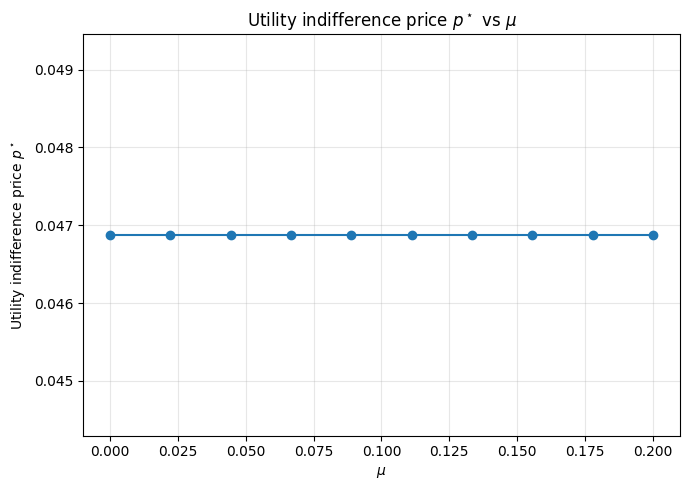

Computing eta = 0.0000
Simulating Paths
Starting Indifference Price Computation
Iter 1: p=0.50000, V0=-0.332641, Vs=-0.212478
Iter 2: p=0.25000, V0=-0.332641, Vs=-0.272801
Iter 3: p=0.12500, V0=-0.332641, Vs=-0.309165
Iter 4: p=0.06250, V0=-0.332641, Vs=-0.329105
Iter 5: p=0.03125, V0=-0.332641, Vs=-0.339505
Iter 6: p=0.04688, V0=-0.332641, Vs=-0.334265
Iter 7: p=0.05469, V0=-0.332641, Vs=-0.331675
Computing eta = 0.0222
Simulating Paths
Starting Indifference Price Computation
Iter 1: p=0.50000, V0=-0.335459, Vs=-0.214156
Iter 2: p=0.25000, V0=-0.335459, Vs=-0.274954
Iter 3: p=0.12500, V0=-0.335459, Vs=-0.311586
Iter 4: p=0.06250, V0=-0.335459, Vs=-0.331732
Iter 5: p=0.03125, V0=-0.335459, Vs=-0.342182
Iter 6: p=0.04688, V0=-0.335459, Vs=-0.336881
Iter 7: p=0.05469, V0=-0.335459, Vs=-0.334294
Iter 8: p=0.05078, V0=-0.335459, Vs=-0.335599
Computing eta = 0.0444
Simulating Paths
Starting Indifference Price Computation
Iter 1: p=0.50000, V0=-0.332373, Vs=-0.211787
Iter 2: p=0.25000, V0=-0

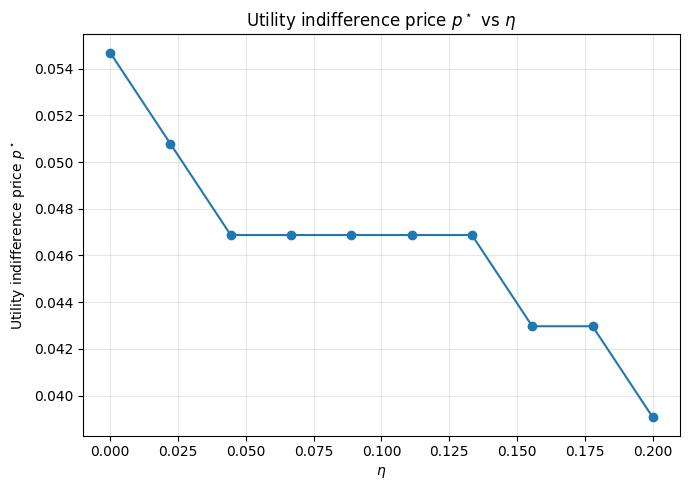

Computing rho = -1.0000
Simulating Paths
Starting Indifference Price Computation
Iter 1: p=0.50000, V0=-0.333676, Vs=-0.210944
Iter 2: p=0.25000, V0=-0.333676, Vs=-0.270874
Iter 3: p=0.12500, V0=-0.333676, Vs=-0.306929
Iter 4: p=0.06250, V0=-0.333676, Vs=-0.326719
Iter 5: p=0.03125, V0=-0.333676, Vs=-0.337129
Iter 6: p=0.04688, V0=-0.333676, Vs=-0.331880
Iter 7: p=0.03906, V0=-0.333676, Vs=-0.334494
Computing rho = -0.7778
Simulating Paths
Starting Indifference Price Computation
Iter 1: p=0.50000, V0=-0.332811, Vs=-0.210855
Iter 2: p=0.25000, V0=-0.332811, Vs=-0.270743
Iter 3: p=0.12500, V0=-0.332811, Vs=-0.306794
Iter 4: p=0.06250, V0=-0.332811, Vs=-0.326639
Iter 5: p=0.03125, V0=-0.332811, Vs=-0.337006
Iter 6: p=0.04688, V0=-0.332811, Vs=-0.331743
Iter 7: p=0.03906, V0=-0.332811, Vs=-0.334356
Iter 8: p=0.04297, V0=-0.332811, Vs=-0.333028
Computing rho = -0.5556
Simulating Paths
Starting Indifference Price Computation
Iter 1: p=0.50000, V0=-0.332922, Vs=-0.211300
Iter 2: p=0.25000, V0

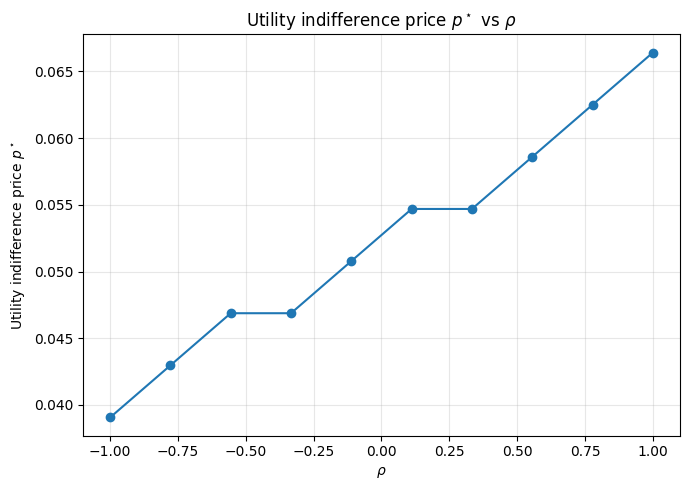

In [40]:
mu_values = np.linspace(0.00, 0.20, 10)

mu_grid, pstar_mu = sweep_mu_and_plot(
    mu_values=mu_values,
    price_low=0.0,
    price_high=1.0,
    tol=1e-3,
    max_iter=20,
    eta=0.1,
    rho=-0.5,
    plot_hist=False,
    show_analytics=False,
    output_dir="Q2/PvsMu"
)

eta_values = np.linspace(0.00, 0.20, 10)

eta_grid, pstar_eta = sweep_eta_and_plot(
    eta_values=eta_values,
    price_low=0.0,
    price_high=1.0,
    tol=1e-3,
    max_iter=20,
    mu=0.1,
    rho=-0.5,
    plot_hist=False,
    show_analytics=False,
    output_dir="Q2/PvsEta"
)

rho_values = np.linspace(-1.0, 1.0, 10)

rho_grid, pstar_rho = sweep_rho_and_plot(
    rho_values=rho_values,
    price_low=0.0,
    price_high=1.0,
    tol=1e-3,
    max_iter=20,
    mu=0.1,
    eta=0.1,
    plot_hist=False,
    show_analytics=False,
    output_dir="Q2/PvsRho"
)

## 9. Strategy Evaluation: Prediction Utilities

To visualise the learned hedging strategies as functions of $(S_t, Y_t)$, we query the trained networks at arbitrary input states. Both networks have input shape $(\text{batch}, N, 3)$, so we tile a single state $(t, S, Y)$ into a dummy sequence of length $N$ and read off the output at position 0.

### 9.1 Baseline policy

`predict_baseline_policy` returns $\phi^0(t, S, Y)$ — the unconstrained optimal hedge position — at any set of input states.

In [72]:
def predict_baseline_policy(model, t_value, S_values, Y_values):
    S_values = np.asarray(S_values, dtype=np.float32)
    Y_values = np.asarray(Y_values, dtype=np.float32)
    t_vec = np.full_like(S_values, t_value, dtype=np.float32)

    row = np.stack([t_vec, S_values, Y_values], axis=-1)  # shape (m, 3)
    X = np.repeat(row[:, None, :], N, axis=1)             # shape (m, N, 3)

    phi0_all = model.predict(X, verbose=0)                # shape (m, N)
    return phi0_all[:, 0]                                  # shape (m,)

### 9.2 Correction policy

`predict_correction_policy` returns $\mathbf{1}_{\{S \geq B\}} \cdot \Delta(t, S, Y)$ — the additional hedging demand placed by the seller relative to the baseline. The alive indicator is applied pointwise: states with $S < B$ represent knocked-out paths where the correction is zero by construction.

In [73]:
def predict_correction_policy(model, t_value, S_values, Y_values, B):
    S_values = np.asarray(S_values, dtype=np.float32)
    Y_values = np.asarray(Y_values, dtype=np.float32)
    t_vec = np.full_like(S_values, t_value, dtype=np.float32)
    alive_vec = (S_values >= B).astype(np.float32)

    row = np.stack([t_vec, S_values, Y_values], axis=-1)  # shape (m, 3)
    X = np.repeat(row[:, None, :], N, axis=1)             # shape (m, N, 3)

    delta_all = model.predict(X, verbose=0)               # shape (m, N)
    delta = delta_all[:, 0]                                # shape (m,)

    return alive_vec * delta, alive_vec                    # shape (m,), (m,)

## 10. Hedging Strategy Visualisation Functions

These functions generate the strategy plots used in the report.

### 10.1 Correction vs $S_t$ at fixed $Y_t$

`plot_hedge_correction_vs_S` plots $\phi^{\text{sell}}(t,S,Y_{\text{fixed}}) - \phi^0(t,S,Y_{\text{fixed}})$ over a grid of $S$ values at several time snapshots $t \in \{0, 0.5, 0.9\}$, with the barrier $B$ marked as a vertical dashed line. The correction drops to zero below $B$ where the option is knocked out.

In [74]:
def plot_hedge_correction_vs_S(save_path, baseline_model, seller_model, B,
                               Y_fixed=0.05, times=(0.0, 0.5, 0.9),
                               S_min=0.5, S_max=1.5, n_S=200, show_barrier=True):

    S_grid = np.linspace(S_min, S_max, n_S, dtype=np.float32)

    plt.figure(figsize=(7, 5))
    for t_val in times:
        Y_grid = np.full_like(S_grid, Y_fixed, dtype=np.float32)
        correction, _ = predict_correction_policy(seller_model, t_val, S_grid, Y_grid, B)
        plt.plot(S_grid, correction, label=f"t = {t_val:.2f}")

    if show_barrier:
        plt.axvline(B, linestyle="--", linewidth=1, color="black", label=f"B = {B}")

    plt.xlabel(r"$S_t$")
    plt.ylabel(r"Hedge correction $\phi^{sell} - \phi^0$")
    plt.title(rf"Hedge correction vs $S_t$ (fixed $Y_t={Y_fixed}$)")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

### 10.2 Correction vs $Y_t$ at fixed $S_t$

`plot_hedge_correction_vs_Y` plots the correction over a grid of $Y_t$ values at a fixed spot level, revealing the variance sensitivity of the hedging adjustment at different points in time.

In [75]:
def plot_hedge_correction_vs_Y(save_path, baseline_model, seller_model, B,
                               S_fixed=1.0, times=(0.0, 0.5, 0.9),
                               Y_min=0.01, Y_max=0.12, n_Y=200):

    Y_grid = np.linspace(Y_min, Y_max, n_Y, dtype=np.float32)

    plt.figure(figsize=(7, 5))
    for t_val in times:
        S_grid = np.full_like(Y_grid, S_fixed, dtype=np.float32)
        correction, _ = predict_correction_policy(seller_model, t_val, S_grid, Y_grid, B)
        plt.plot(Y_grid, correction, label=f"t = {t_val:.2f}")

    plt.xlabel(r"$Y_t$")
    plt.ylabel(r"Hedge correction $\phi^{sell} - \phi^0$")
    plt.title(rf"Hedge correction vs $Y_t$ (fixed $S_t={S_fixed}$)")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

### 10.3 Multi-panel wrappers

These wrappers loop over several fixed levels of $Y_t$ or $S_t$ respectively, generating one figure per level and saving each to a filing path.

In [76]:
def plot_hedge_correction_vs_S_multiple_Y(
    baseline_model, seller_model, B, Y_fixed_values,
    times=(0.0, 0.5, 0.9), S_min=0.5, S_max=1.5, n_S=200,
    show_barrier=True, output_dir="Q2/HedgeStratVsS"):

    os.makedirs(output_dir, exist_ok=True)
    for Y_fixed in Y_fixed_values:
        save_path = os.path.join(output_dir, f"hedge_correction_vs_S_fixedY_{Y_fixed:.3f}.png")
        plot_hedge_correction_vs_S(
            save_path=save_path, baseline_model=baseline_model, seller_model=seller_model,
            B=B, Y_fixed=Y_fixed, times=times, S_min=S_min, S_max=S_max,
            n_S=n_S, show_barrier=show_barrier
        )


def plot_hedge_correction_vs_Y_multiple_S(
    baseline_model, seller_model, B, S_fixed_values,
    times=(0.0, 0.5, 0.9), Y_min=0.01, Y_max=0.12,
    n_Y=200, output_dir="Q2/HedgeStratVsY"):

    os.makedirs(output_dir, exist_ok=True)
    for S_fixed in S_fixed_values:
        save_path = os.path.join(output_dir, f"hedge_correction_vs_Y_fixedS_{S_fixed:.3f}.png")
        plot_hedge_correction_vs_Y(
            save_path=save_path, baseline_model=baseline_model, seller_model=seller_model,
            B=B, S_fixed=S_fixed, times=times, Y_min=Y_min, Y_max=Y_max, n_Y=n_Y
        )

### 10.4 Barrier variation

`plot_hedge_correction_vs_S_multiple_B` generates one hedge correction vs $S_t$ plot for each barrier level in $B \in \{0.4, 0.7, 1.0, 1.4\}$, holding $Y_t$ fixed. A higher $B$ places the knock-out boundary closer to the initial spot $s_0 = 1$, increasing the knock-out probability and substantially changing the seller's delta exposure near the boundary.

In [77]:
def plot_hedge_correction_vs_S_for_B(
    baseline_model, seller_model, B, Y_fixed=0.05,
    times=(0.0, 0.5, 0.9), S_min=0.5, S_max=1.5,
    n_S=200, show_barrier=True, save_path=None):

    S_grid = np.linspace(S_min, S_max, n_S, dtype=np.float32)

    plt.figure(figsize=(7, 5))
    for t_val in times:
        Y_grid = np.full_like(S_grid, Y_fixed, dtype=np.float32)
        correction, _ = predict_correction_policy(seller_model, t_val, S_grid, Y_grid, B)
        plt.plot(S_grid, correction, label=f"t = {t_val:.2f}")

    if show_barrier:
        plt.axvline(B, linestyle="--", linewidth=1, color="black", label=f"B = {B:.3f}")

    plt.xlabel(r"Spot price $S_t$")
    plt.ylabel(r"Hedge correction $\phi^{sell} - \phi^0$")
    plt.title(rf"Hedge correction vs $S_t$ (fixed $Y_t={Y_fixed:.3f}$, $B={B:.3f}$)")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_hedge_correction_vs_S_multiple_B(
    baseline_model, seller_model, B_values, Y_fixed=0.05,
    times=(0.0, 0.5, 0.9), S_min=0.5, S_max=1.5,
    n_S=200, show_barrier=True, output_dir="Q2/HedgeStratVsS_BVariation"):

    os.makedirs(output_dir, exist_ok=True)
    for B in B_values:
        save_path = os.path.join(output_dir, f"hedge_correction_vs_S_fixedY_{Y_fixed:.3f}_B_{B:.3f}.png")
        plot_hedge_correction_vs_S_for_B(
            baseline_model=baseline_model, seller_model=seller_model,
            B=B, Y_fixed=Y_fixed, times=times, S_min=S_min, S_max=S_max,
            n_S=n_S, show_barrier=show_barrier, save_path=save_path
        )

## 11. Main Run: Baseline Indifference Price Estimation

We now execute the complete pipeline at the baseline parameters $(\mu, \eta, \rho) = (0.1, 0.1, -0.5)$. This involves:
1. Simulating $80{,}000$ training and $20{,}000$ validation Heston paths.
2. Training the baseline model to convergence (50 epochs).
3. Running up to 20 bisection iterations to find $p^\star$ such that $|V_s(p^\star) - V_0| < 10^{-3}$.
4. Printing training region diagnostics to confirm adequate coverage of the near-barrier region.
5. Saving the training and validation loss curves for both the baseline and the final correction model.

The returned `baseline_model` and `seller_model` (correction network) are used in all subsequent hedging strategy visualisations.

Simulating Paths
=== Training state coverage summary ===
Total decision-time states: 20,160,000
Alive states: 19,643,870 (97.440% of total)

Near-barrier alive region:
  Count: 575,397
  % of total: 2.8542%
  % of alive: 2.9291%

High-S alive region:
  Count: 3,341,847
  % of total: 16.5766%
  % of alive: 17.0122%

ITM alive region (S < K):
  Count: 7,533,253
  % of total: 37.3673%
  % of alive: 38.3491%

OTM alive region (S >= K):
  Count: 12,110,617
  % of total: 60.0725%
  % of alive: 61.6509%

Starting Indifference Price Computation
Iter 1: p=0.50000, V0=-0.333379, Vs=-0.211734
Iter 2: p=0.25000, V0=-0.333379, Vs=-0.271829
Iter 3: p=0.12500, V0=-0.333379, Vs=-0.308061
Iter 4: p=0.06250, V0=-0.333379, Vs=-0.327924
Iter 5: p=0.03125, V0=-0.333379, Vs=-0.338349
Iter 6: p=0.04688, V0=-0.333379, Vs=-0.333142


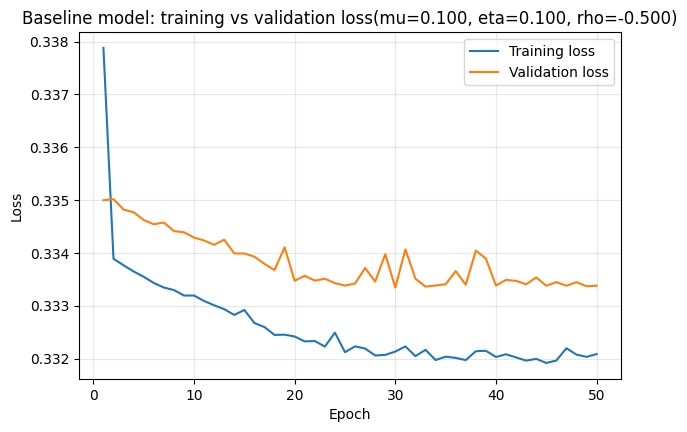

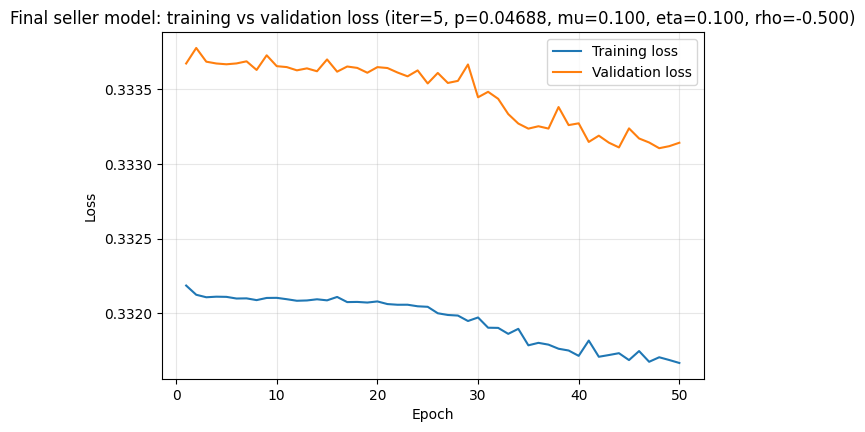

In [78]:
price_star, baseline_model, seller_model, V0 = estimate_indifference_price_tf(
    price_low=0.0,
    price_high=1.0,
    tol=1e-3,
    max_iter=20,
    plot_hist=True,mu=0.1,eta=0.1,rho=-0.5,show_analytics=True,output_dir="Q2/HedgeStrat"
)

## 12. Hedging Strategy Analysis

### 12.1 Effect of $S_t$, $Y_t$ and knock-out level $B$

We visualise the hedge correction $\phi^{\text{sell}} - \phi^0$ across the state space $(S_t, Y_t)$ to understand how the seller's additional hedging demand depends on the key state variables.

Varying $S_t$ at fixed $Y_t$: For each of several instantaneous variance levels $Y_t \in \{0.02, 0.05, 0.10, 0.20\}$, we plot the correction over $S_t \in [0.5, 1.5]$. We expect the correction to be largest for paths near the barrier (large put delta, high knock-out risk) and to decay as $S$ moves away from $B$. The correction should drop to zero below $B$ by construction.

Varying $Y_t$ at fixed $S_t$: For each of several spot levels $S_t \in \{0.7, 0.8, 1.0, 1.5\}$, we plot the correction over $Y_t \in [0.01, 0.12]$. Higher variance increases the probability of hitting the barrier and of large put payoffs, so we expect the correction to be sensitive to $Y_t$ especially when the option is near-the-money.

Varying $B$: We retrain the seller model at barrier levels $B \in \{0.4, 0.70, 1.0, 1.4\}$ (using the same pre-trained baseline) and generate one hedge correction plot per barrier. A higher $B$ places the knock-out boundary closer to the initial spot, increasing the knock-out probability substantially and changing the seller's effective delta exposure near $B$.

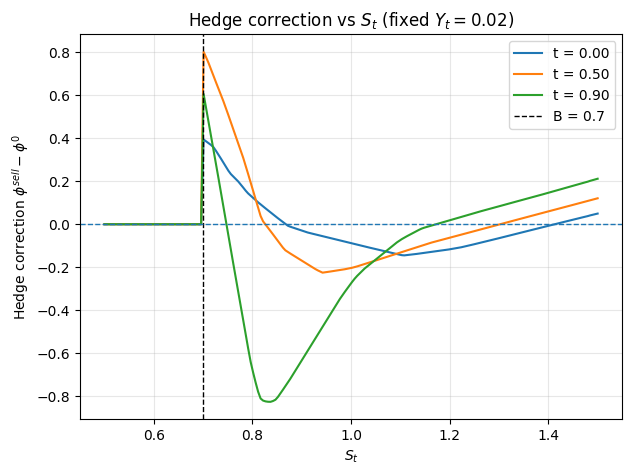

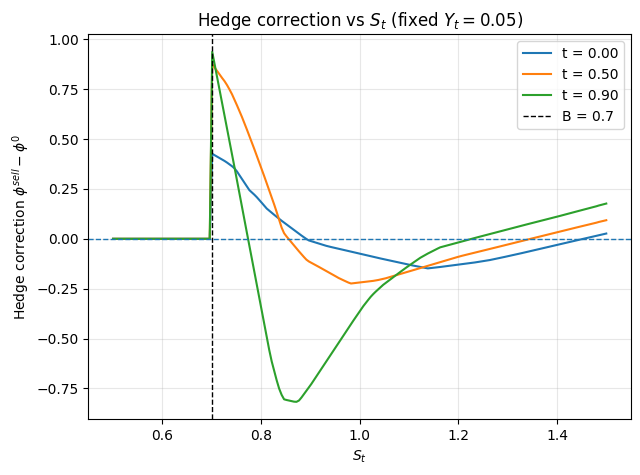

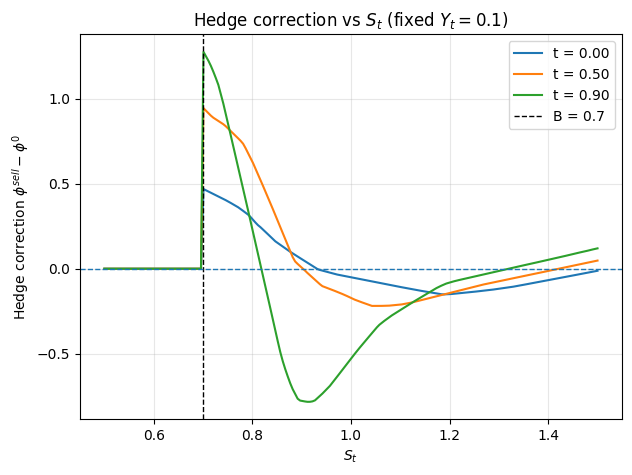

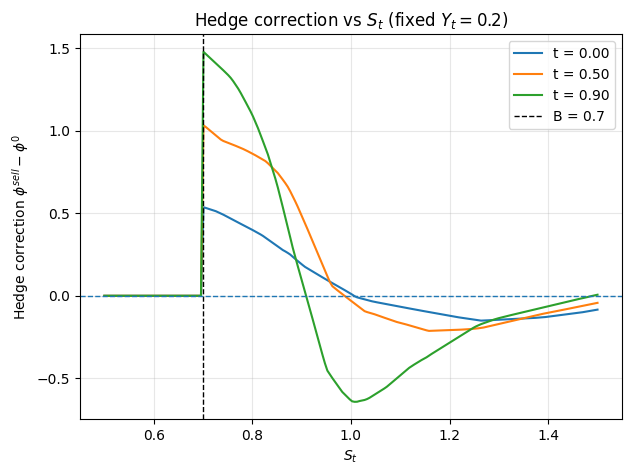

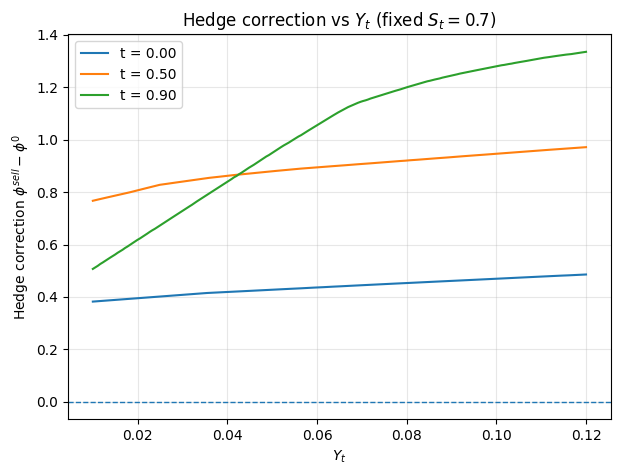

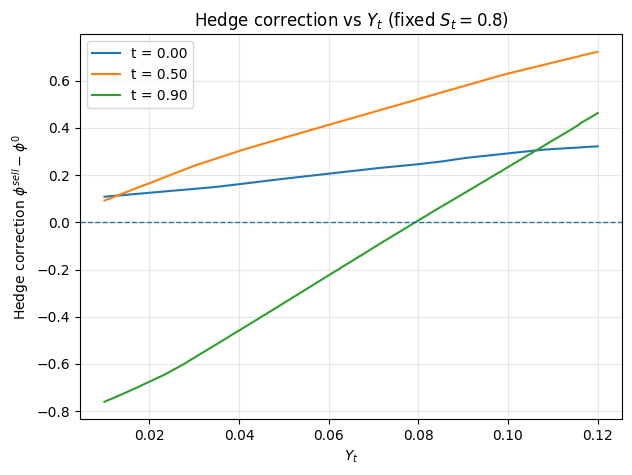

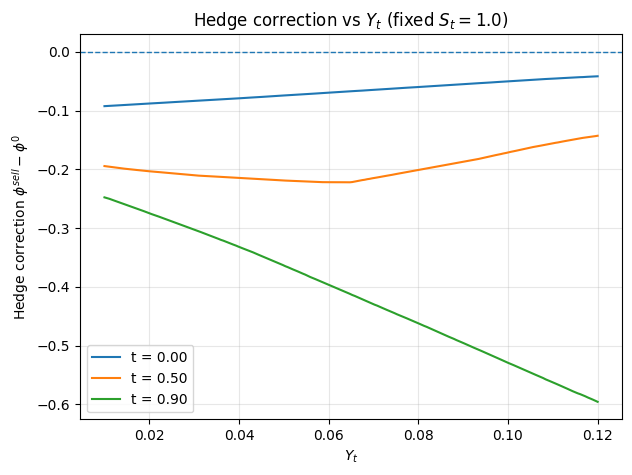

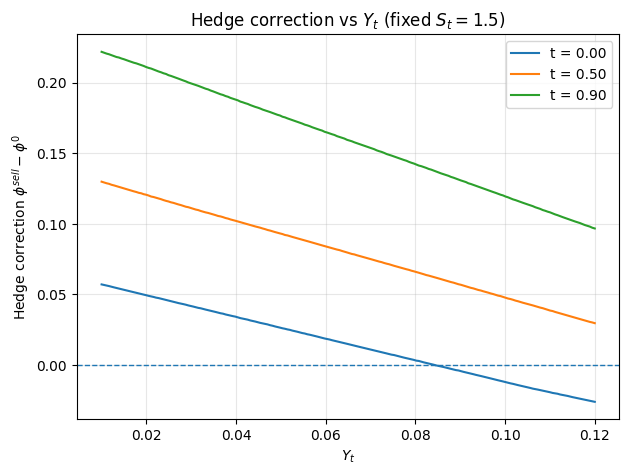

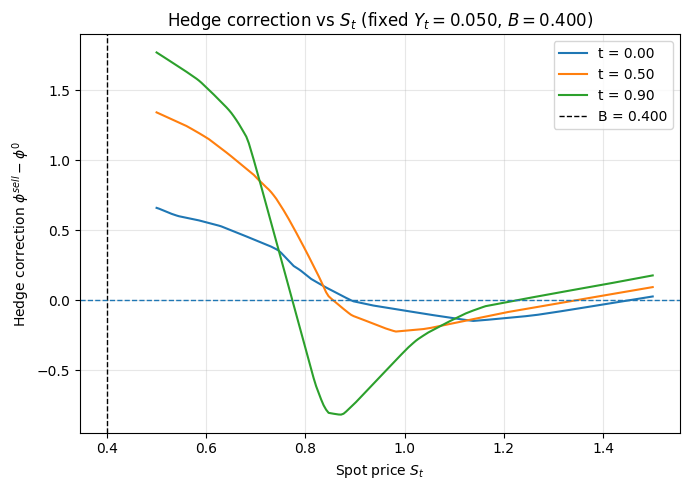

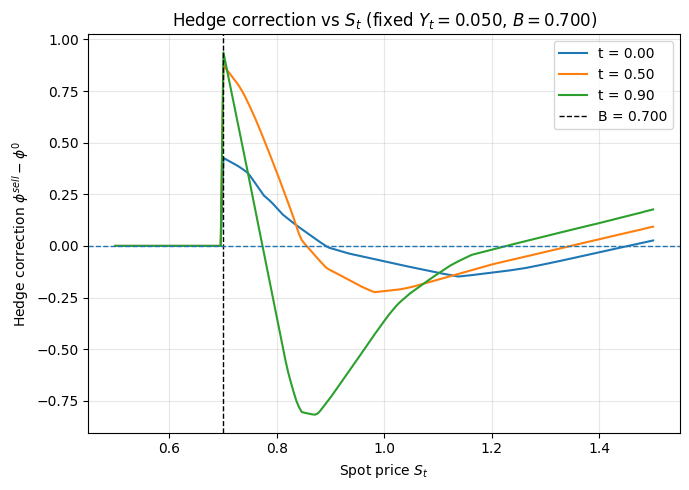

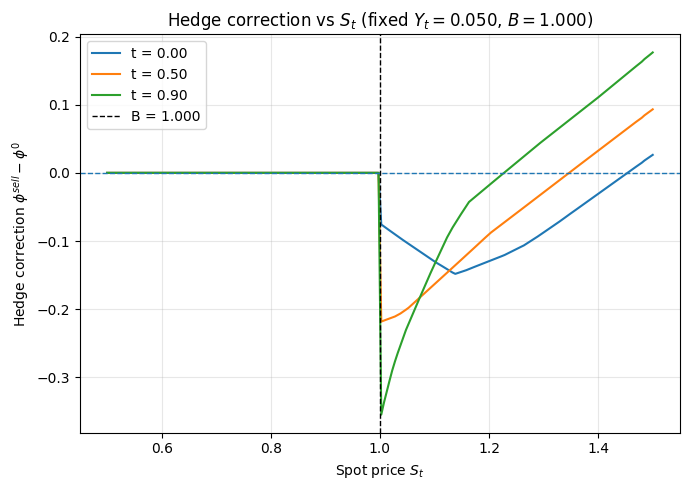

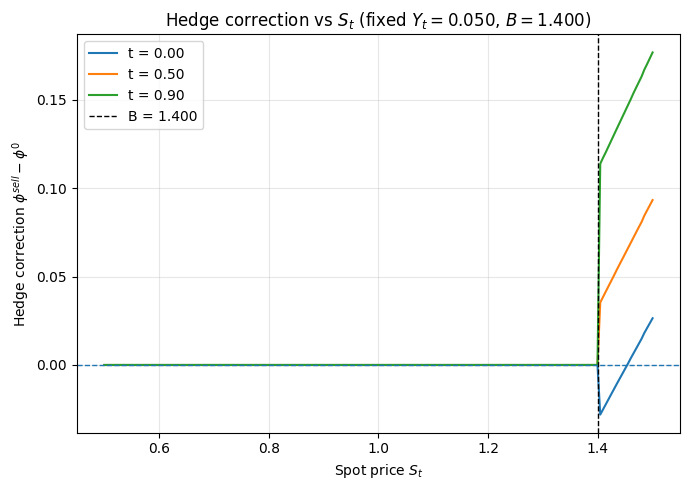

In [79]:
plot_hedge_correction_vs_S_multiple_Y(
    baseline_model=baseline_model,
    seller_model=seller_model,
    B=B_barrier,
    Y_fixed_values=[0.02, 0.05, 0.1, 0.2],  
    times=(0.0, 0.5, 0.9),
    S_min=0.5,
    S_max=1.5,
    n_S=200,
    show_barrier=True,
    output_dir="Q2/HedgeStratVsS"
)

plot_hedge_correction_vs_Y_multiple_S(
    baseline_model=baseline_model,
    seller_model=seller_model,
    B=B_barrier,
    S_fixed_values=[0.7, 0.8, 1.0, 1.5],      
    times=(0.0, 0.5, 0.9),
    Y_min=0.01,
    Y_max=0.12,
    n_Y=200,
    output_dir="Q2/HedgeStratVsY"
)

plot_hedge_correction_vs_S_multiple_B(
    baseline_model=baseline_model,
    seller_model=seller_model,
    B_values=[0.4, 0.70, 1.0, 1.4],   # choose your 3 barrier values
    Y_fixed=0.05,
    times=(0.0, 0.5, 0.9),
    S_min=0.5,
    S_max=1.5,
    n_S=200,
    show_barrier=True,
    output_dir="Q2/HedgeStratVsS_BVariation",
)

*End of Question 2 and project notebook*